# Gauging Large Language Models for Generative Story Evaluation

#### **Course:** IT 469 — Human Language Technologies  
#### **Section:** 62720
#### **Group:** 2  

**Team Members:**  
- Nouf AlMansour — 444200525  
- Nour AlGhomlas — 444200811
- Tarfah Bin Moammar — 444200611  
- Shahad AlMutairi — 444200935  
- Lujain AlHarbi — 443200811

**Supervisor:** Dr. Hend AlRasheed  
**Semester:** 2nd Semester, Spring '26

> This notebook documents our analysis of **How do different prompting techniques affect LLM story evaluation compared to human judgments?**, including exploratory analysis, statistical comparisons, model evaluation, and practical insights for automated story assessment.


---






### Project Overview

**Task:** Evaluate how well large language models assess story quality compared to human judgments across different prompting strategies.

**Input:** 1,056 human-annotated stories from the HANNA dataset, evaluated by Claude (3 variants) and GPT-4.1 Mini using five prompting techniques.

**Output:** Comparative analysis of alignment metrics (error rates, accuracy, correlation) between human and LLM evaluations.

**Significance:** Determines feasibility of automated story evaluation, identifies optimal prompting strategies, and reveals which narrative dimensions LLMs can reliably assess.

#### What we'll show
1. Load and combine evaluation data from multiple LLM sources  
2. Preprocess and validate data quality (missing values, consistency checks, balanced dataset)
3. Explore data patterns through visualizations (distributions, correlations, technique effects)
4. Define performance metrics for story evaluation (MAE, accuracy, correlation)
5. Compare 5 prompting techniques across 6 story quality metrics  
6. Conduct comprehensive head-to-head model comparisons  
7. Validate consistency across Claude model versions  
8. Identify optimal prompting strategies for automated story evaluation
---

### Models and Techniques

**Models Used:**

**Claude Models** - [Data Folder](https://drive.google.com/drive/folders/14kdjl_DW0xFZapC57ocoCHu86GebhOEG?usp=share_link)
- Claude 3 Haiku (claude-3-haiku-20240307): Role 1 only
- Claude Haiku 4.5 (claude-haiku-4-5-20251001): Instruction-Based only
- Claude Sonnet 4.5 (claude-sonnet-4-5-20250929): Role 1, 2, 3, Zero-Shot

**GPT Model** - [Data Folder](https://drive.google.com/drive/folders/1a9Sb2MSMFKHpSOKbEErBXNqZpSwYUU_l?usp=share_link)
- GPT-4.1 Mini (gpt-4.1-mini): All 5 techniques

**Prompting Techniques:** - [Prompts Folder](https://drive.google.com/drive/folders/1YIZ4f6LVvqjjB1J1Ppj3RhvjOVV9q0RP?usp=share_link)
1. **Role 1** - Human Annotator: Trained annotator following research guidelines
2. **Role 2** - Story Expert: Expert focusing on structure, emotion, and flow
3. **Role 3** - Creative Writing Professor: 20+ years experience with detailed rubric
4. **Instruction-Based**:
5. **Zero-Shot**:

> **Note:** Different Claude versions were used based on data availability. Role 1 was evaluated with both Claude 3 Haiku and Claude Sonnet 4.5 to validate consistency.

**Story Evaluation Dimensions (1-5 scale):**
- **Relevance**: How well the story matches the prompt
- **Coherence**: Logical consistency and structure  
- **Empathy**: Emotional depth and resonance
- **Surprise**: Originality and unexpectedness
- **Engagement**: How captivating the story is
- **Complexity**: Narrative richness and sophistication

---


1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Preprocessing](#2-data-preprocessing)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Metric Definitions](#4-metric-definitions)
5. [Model & Technique Evaluation](#5-model--technique-evaluation)
6. [Summary & Recommendations](#6-summary--recommendations)
7. [Future Work](#7-future-work)

# 1. Setup & Data Loading


## 1.1 Import Libraries
We begin by importing the necessary Python libraries for data manipulation, statistical analysis, and visualization.


In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for metrics
from sklearn.metrics import mean_absolute_error, accuracy_score

# Scipy for statistical tests
from scipy.stats import spearmanr, wilcoxon, ttest_rel

# Visualization settings
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

---

## 1.2 Load Data Files
Our evaluation data is stored in a [GitHub repository](https://github.com/noorge/NLP_Story_Evaluation_Analysis) and organized into separate CSV files:

**GPT-4.1 Mini evaluations** (5 files):
- `gpt_role1.csv` - Role-based prompt: "You are a human annotator"
- `gpt_role2.csv` - Role-based prompt: "You are a story expert"  
- `gpt_role3.csv` - Role-based prompt: "You are a creative writing professor"
- `gpt_instruction.csv` - Instruction-based: Direct evaluation instructions
- `gpt_zeroshot.csv` - Zero-shot: Minimal prompting

**Claude Sonnet 4.5 evaluations** (4 files):
- `claude_role1_sonnet45.csv` - Sonnet 4.5 with Role 1
- `claude_role2_sonnet45.csv` - Sonnet 4.5 with Role 2
- `claude_role3_sonnet45.csv` - Sonnet 4.5 with Role 3
- `claude_zeroshot_sonnet45.csv` - Sonnet 4.5 with Zero-shot

**Claude Haiku evaluations** (2 files):
- `claude_instruction_haiku45.csv` - Haiku 4.5 with Instruction-based
- `claude_role1_haiku45.csv` - Haiku 4.5 with Role 1 (EXCLUDED from main analysis, saved for Section 5.3 version validation)

Each file contains 1,056 stories with human ratings and LLM-generated scores across 6 quality dimensions:
- **relevance**, **coherence**, **empathy**, **surprise**, **engagement**, **complexity**

> **Note**: The main analysis uses 9 model-technique combinations (GPT: 5 techniques, Claude Sonnet: 4 techniques). Claude Haiku Role 1 is excluded from the main dataset to avoid duplicate Role 1 evaluations, and is preserved separately for version validation in Section 5.3.

In [ ]:
# Download and extract data from GitHub
!wget https://github.com/noorge/NLP_Story_Evaluation_Analysis/raw/main/Data.zip

--2026-05-14 18:02:29--  https://github.com/noorge/NLP_Story_Evaluation_Analysis/raw/main/Data.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/noorge/NLP_Story_Evaluation_Analysis/main/Data.zip [following]
--2026-05-14 18:02:29--  https://raw.githubusercontent.com/noorge/NLP_Story_Evaluation_Analysis/main/Data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25043072 (24M) [application/zip]
Saving to: ‘Data.zip’

Data.zip            100%[===================>]  23.88M  --.-KB/s    in 0.1s    

2026-05-14 18:02:30 (206 MB/s) - ‘Data.zip’ saved [25043072/25043072]



In [ ]:
# Extract the zip file
with zipfile.ZipFile("Data.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
# Verify data structure
BASE_PATH = "/content/Data"

GPT_PATH = os.path.join(BASE_PATH, "gpt_results")
CLAUDE_PATH = os.path.join(BASE_PATH, "claude_results")

print(os.listdir(GPT_PATH))
print(os.listdir(CLAUDE_PATH))

['gpt_instruction.csv', 'gpt_role2.csv', 'gpt_role3.csv', 'gpt_role1.csv', 'gpt_zeroshot.csv']
['claude_instruction_haiku45.csv', 'claude_zeroshot_sonnet45.csv', 'claude_role2_sonnet45.csv', 'claude_role1_sonnet45.csv', 'claude_role1_haiku3.csv', 'claude_role3_sonnet45.csv']



**Next step**: Load individual files and examine their structure.

---

## 1.3 Load Individual Files

We load each CSV file separately to verify structure and content before combining them into a unified dataset. This allows us to:
- Confirm consistent schema across files
- Identify any data quality issues early
- Add metadata (model, technique, version) to each file

In [ ]:
# Define metrics
metrics = ['relevance', 'coherence', 'empathy', 'surprise', 'engagement', 'complexity']

# Load GPT files
gpt_files = {
    'role_1': 'gpt_role1.csv',
    'role_2': 'gpt_role2.csv',
    'role_3': 'gpt_role3.csv',
    'instruction': 'gpt_instruction.csv',
    'zero_shot': 'gpt_zeroshot.csv'
}

gpt_data = {}
for technique, filename in gpt_files.items():
    filepath = os.path.join(GPT_PATH, filename)
    df = pd.read_csv(filepath)
    df['model'] = 'GPT'
    df['technique'] = technique
    df['model_version'] = 'gpt-4.1-mini'
    gpt_data[technique] = df
    print(f"✓ Loaded {filename}: {len(df)} stories")

print()

# Load Claude files
claude_files = {
    'role_1': 'claude_role1_haiku3.csv',
    'role_2': 'claude_role2_sonnet45.csv',
    'role_3': 'claude_role3_sonnet45.csv',
    'zero_shot': 'claude_zeroshot_sonnet45.csv'
}

claude_data = {}
for technique, filename in claude_files.items():
    filepath = os.path.join(CLAUDE_PATH, filename)
    df = pd.read_csv(filepath)
    df['model'] = 'Claude'
    df['technique'] = technique
    # Infer version from filename
    if 'haiku' in filename.lower():
        df['model_version'] = 'claude-3-haiku'
    else:
        df['model_version'] = 'claude-3.5-sonnet'
    claude_data[technique] = df
    print(f"✓ Loaded {filename}: {len(df)} stories")

print(f"\n Total datasets loaded: {len(gpt_data) + len(claude_data)}")
print(f" GPT techniques: {len(gpt_data)}")
print(f" Claude techniques: {len(claude_data)}")

✓ Loaded gpt_role1.csv: 1056 stories
✓ Loaded gpt_role2.csv: 1056 stories
✓ Loaded gpt_role3.csv: 1056 stories
✓ Loaded gpt_instruction.csv: 1056 stories
✓ Loaded gpt_zeroshot.csv: 1056 stories

✓ Loaded claude_role1_haiku3.csv: 1056 stories
✓ Loaded claude_role2_sonnet45.csv: 1056 stories
✓ Loaded claude_role3_sonnet45.csv: 1056 stories
✓ Loaded claude_zeroshot_sonnet45.csv: 1056 stories

 Total datasets loaded: 9
 GPT techniques: 5
 Claude techniques: 4


All expected files present and loaded successfully. Ready for preprocessing and combination.

# 2. Data Preprocessing

## 2.1 Combine Datasets

We load all evaluation files and combine them strategically:

**Main analysis dataset**: Excludes Claude 3 Haiku Role 1 (this will be used only for version validation in Section 4.3)  
**Haiku Role 1 dataset**: Saved separately for Section 4.3 version comparison against Sonnet 4.5

This approach ensures:
- Clean main analysis with 9 model-technique combinations
- Haiku data preserved for version validation later
- No duplicate Role 1 evaluations in the main dataset

> Each row represents one story evaluated by one specific model-technique combination.

In [ ]:
def get_technique(filename):
    name = filename.lower()

    if "zero" in name:
        return "zero_shot"
    elif "instruction" in name:
        return "instruction"
    elif "role1" in name:
        return "role_1"
    elif "role2" in name:
        return "role_2"
    elif "role3" in name:
        return "role_3"
    else:
        return "unknown"


def get_claude_version(filename):
    name = filename.lower()

    if "haiku" in name:
        return "claude-3-haiku"
    elif "sonnet" in name:
        return "claude-3.5-sonnet"
    else:
        return "unknown"


def load_with_metadata(path, filename, model):
    df = pd.read_csv(os.path.join(path, filename))

    df["model"] = model
    df["source_file"] = filename
    df["technique"] = get_technique(filename)

    if model == "GPT":
        df["model_version"] = "gpt-4.1-mini"
    else:
        df["model_version"] = get_claude_version(filename)

    return df

In [ ]:
# Load all files
gpt_dfs = [load_with_metadata(GPT_PATH, f, "GPT") for f in os.listdir(GPT_PATH)]
claude_dfs = [load_with_metadata(CLAUDE_PATH, f, "Claude") for f in os.listdir(CLAUDE_PATH)]
all_dfs = gpt_dfs + claude_dfs


# SAVE Haiku Role 1 BEFORE filtering it out
haiku_role1_df = None
for df in all_dfs:
    if (df["model"].iloc[0] == "Claude" and
        df["technique"].iloc[0] == "role_1" and
        df["model_version"].iloc[0] == "claude-3-haiku"):
        haiku_role1_df = df.copy()
        print(f"✓ Saved Haiku Role 1 for Section 4.3: {len(haiku_role1_df)} stories")
        break


# Remove ONLY Claude role1 Haiku during combining
filtered_dfs = [
    df for df in all_dfs
    if not (
        df["model"].iloc[0] == "Claude" and
        df["technique"].iloc[0] == "role_1" and
        df["model_version"].iloc[0] == "claude-3-haiku"
    )
]

# Combine
combined_df = pd.concat(filtered_dfs, ignore_index=True)
print("\n=== MAIN ANALYSIS DATASET ===")
print("Combined shape:", combined_df.shape)

✓ Saved Haiku Role 1 for Section 4.3: 1056 stories

=== MAIN ANALYSIS DATASET ===
Combined shape: (10560, 37)


**Main analysis dataset:**
- **10,560 evaluations** (10 model-technique combinations)
- GPT-4.1 Mini: 5 techniques (Role 1, 2, 3, Instruction, Zero-Shot)
- Claude Sonnet 4.5: 4 techniques (Role 1, 2, 3, Zero-Shot)
- Claude Haiku 4.5: 1 technique (Instruction)

**Haiku Role 1 dataset:**
- **~1,056 evaluations** stored in `haiku_role1_df` variable
- Will be loaded in Section 4.3 for Haiku vs Sonnet comparison
- Same stories, same technique, different Claude version

> This prevents duplicate Role 1 evaluations in main analysis while preserving data for version validation study.


In [ ]:
print("Combined shape:", combined_df.shape)
combined_df.head()

Combined shape: (10560, 37)


,story_id,source_model,original_prompt,human_reference_story,story,human_relevance,human_coherence,human_empathy,human_surprise,human_engagement,human_complexity,judge_model,prompt_version,repeats_requested,successful_runs,relevance_runs,coherence_runs,empathy_runs,surprise_runs,engagement_runs,complexity_runs,justifications_runs,raw_responses,run_statuses,run_errors,avg_input_tokens,avg_output_tokens,avg_relevance,avg_coherence,avg_empathy,avg_surprise,avg_engagement,avg_complexity,model,source_file,technique,model_version
0,0,Human,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",3.6667,3.6667,2.3333,2.3333,3.3333,2.6667,gpt-4.1-mini,Instruction based prompting,3,3,"[5, 5, 5]","[5, 5, 5]","[4, 4, 4]","[4, 4, 4]","[5, 5, 5]","[4, 4, 4]","[{""relevance"": ""The story directly addresses t...","[""{\n \""relevance\"": 5,\n \""coherence\"": 5,\...","[{""parse_success"": true, ""input_tokens"": 824, ...","[null, null, null]",824.0000,205.0000,5.0000,5.0000,4.0000,4.0000,5.0000,4.0000,GPT,gpt_instruction.csv,instruction,gpt-4.1-mini
1,1,Human,A new law is enacted that erases soldiers memo...,"“Dad, you 're on TV again !” I heard Eric 's v...","“Dad, you 're on TV again !” I heard Eric 's v...",5.0000,4.6667,4.0000,3.6667,3.6667,4.0000,gpt-4.1-mini,Instruction based prompting,3,3,"[5, 5, 5]","[4, 4, 5]","[4, 4, 4]","[3, 3, 3]","[4, 4, 4]","[3, 3, 4]","[{""relevance"": ""The story directly addresses t...","[""{\n \""relevance\"": 5,\n \""coherence\"": 4,\...","[{""parse_success"": true, ""input_tokens"": 860, ...","[null, null, null]",860.0000,187.6667,5.0000,4.3333,4.0000,3.0000,4.0000,3.3333,GPT,gpt_instruction.csv,instruction,gpt-4.1-mini
2,2,Human,A scientific study proves that all humans have...,"When Tyler entered the ward, his daughter Vale...","When Tyler entered the ward, his daughter Vale...",4.6667,4.6667,4.0000,4.3333,4.0000,4.3333,gpt-4.1-mini,Instruction based prompting,3,3,"[4, 5, 5]","[5, 5, 5]","[5, 5, 5]","[3, 4, 4]","[4, 5, 5]","[4, 4, 5]","[{""relevance"": ""The story aligns well with the...","[""{\n \""relevance\"": 4,\n \""coherence\"": 5,\...","[{""parse_success"": true, ""input_tokens"": 1568,...","[null, null, null]",1568.0000,215.6667,4.6667,5.0000,5.0000,3.6667,4.6667,4.3333,GPT,gpt_instruction.csv,instruction,gpt-4.1-mini
3,3,Human,Write a story about an elderly wizard and his ...,His body was failing. He had taken care of it ...,His body was failing. He had taken care of it ...,3.6667,4.0000,3.0000,2.0000,3.6667,4.0000,gpt-4.1-mini,Instruction based prompting,3,3,"[5, 5, 5]","[4, 4, 4]","[4, 4, 4]","[4, 4, 4]","[4, 4, 4]","[4, 4, 4]","[{""relevance"": ""The story directly addresses t...","[""{\n \""relevance\"": 5,\n \""coherence\"": 4,\...","[{""parse_success"": true, ""input_tokens"": 1532,...","[null, null, null]",1532.0000,189.0000,5.0000,4.0000,4.0000,4.0000,4.0000,4.0000,GPT,gpt_instruction.csv,instruction,gpt-4.1-mini
4,4,Human,"You have become death, destroyer of worlds.","I saw the button. It was simple, red, no words...","I saw the button. It was simple, red, no words...",4.6667,5.0000,3.0000,4.6667,3.6667,3.6667,gpt-4.1-mini,Instruction based prompting,3,3,"[5, 5, 5]","[5, 5, 5]","[4, 4, 4]","[3, 3, 3]","[4, 4, 4]","[3, 3, 3]","[{""relevance"": ""The story directly addresses t...","[""{\n \""relevance\"": 5,\n \""coherence\"": 5,\...","[{""parse_success"": true, ""input_tokens"": 720, ...","[null, null, null]",720.0000,189.3333,5.0000,5.0000,4.0000,3.0000,4.0000,3.0000,GPT,gpt_instruction.csv,instruction,gpt-4.1-mini


- **Total rows**: ~10,560 evaluations (1,056 stories × 10 model-technique combinations)
- **Unique stories**: 1,056 (each story appears multiple times with different evaluations)
- **Models**: Claude, GPT
- **Techniques**: instruction, role_1, role_2, role_3, zero_shot
- **Model versions**: claude-3-haiku, claude-3.5-sonnet, gpt-4.1-mini

**Column structure**:
- Story metadata: story_id, source_model, original_prompt, human_reference_story
- Human ratings: human_relevance, human_coherence, human_empathy, human_surprise, human_engagement, human_complexity
- LLM scores: avg_relevance, avg_coherence, avg_empathy, avg_surprise, avg_engagement, avg_complexity
- Metadata: model, technique, model_version

**Data is now ready** for validation.

---

## 2.2 Data Quality Validation

Before analysis, we perform comprehensive data quality checks:

### 2.2.1 Missing Value Analysis

We check for missing values in human ratings and LLM scores. Missing human ratings cannot be imputed (they're ground truth), while missing LLM scores indicate evaluation failures.

In [ ]:
# Check for missing values
score_cols = [
    "human_relevance", "human_coherence", "human_empathy",
    "human_surprise", "human_engagement", "human_complexity",
    "avg_relevance", "avg_coherence", "avg_empathy",
    "avg_surprise", "avg_engagement", "avg_complexity"
]

missing = combined_df[score_cols].isnull().sum()
print(missing)

print(f"\nTotal missing values: {missing.sum()}")
print(f"Percentage: {(missing.sum() / (len(combined_df) * len(score_cols)) * 100):.2f}%")

human_relevance     0
human_coherence     0
human_empathy       0
human_surprise      0
human_engagement    0
human_complexity    0
avg_relevance       3
avg_coherence       3
avg_empathy         3
avg_surprise        3
avg_engagement      3
avg_complexity      3
dtype: int64

Total missing values: 18
Percentage: 0.01%


- All 1,056 stories have complete human expert ratings across all 6 dimensions
- LLM evaluation success rate: 99.99% (only 18 failures out of ~63,000 total score fields)
- Missing LLM scores represent genuine evaluation failures (not data entry errors)
- Missing values distributed across different models and techniques (not systematic to one configuration)

**Decision**: Delete entire stories that have any missing LLM scores. Since each story should appear exactly 10 times (once per model-technique combination), removing stories with incomplete data ensures perfect balance across all configurations.

>The missing values are well below the 5% threshold for safe deletion, representing only 0.17% of the dataset.

In [ ]:
# Identify stories with any missing LLM scores
score_cols = [f'avg_{m}' for m in metrics]
stories_with_missing = combined_df[combined_df[score_cols].isnull().any(axis=1)]['story_id'].unique()

print(f"Stories with missing LLM scores: {len(stories_with_missing)}")
print(f"Story IDs: {stories_with_missing.tolist()}")

# Remove ALL rows for these stories (delete entire stories)
combined_df = combined_df[~combined_df['story_id'].isin(stories_with_missing)]

print(f"\nAfter removing stories with missing values:")
print(f"Total evaluations: {len(combined_df):,}")
print(f"Unique stories: {combined_df['story_id'].nunique():,}")

# Verify all stories now appear exactly 10 times
story_counts = combined_df['story_id'].value_counts()
print(f"\nStory appearance distribution:")
print(story_counts.value_counts())
print(f"Min: {story_counts.min()}, Max: {story_counts.max()}")
print("New shape:", combined_df.shape)

Stories with missing LLM scores: 2
Story IDs: [923, 413]

After removing stories with missing values:
Total evaluations: 10,540
Unique stories: 1,054

Story appearance distribution:
count
10    1054
Name: count, dtype: int64
Min: 10, Max: 10
New shape: (10540, 37)


In [ ]:
combined_df[score_cols].isnull().sum()

,0
avg_relevance,0
avg_coherence,0
avg_empathy,0
avg_surprise,0
avg_engagement,0
avg_complexity,0



**Stories removed**: 2 stories (IDs: 413, 923) with missing LLM scores  
**Rows removed**: 20 evaluations (2 stories × 10 combinations)

**Final dataset**:
- **10,540 complete evaluations**
- **1,054 unique stories** (each appearing exactly 10 times)
- **Perfect balance**: Every story has all 10 model-technique evaluations ✓


All remaining rows now have complete human ratings and LLM scores. Dataset is perfectly balanced for analysis.

---

### 2.2.2 Human Score Consistency Check
Since the same story should have identical human ratings across all model-technique combinations, we verify this consistency. Any inconsistencies would indicate data integrity issues.

In [ ]:
human_cols = [
    "human_relevance", "human_coherence", "human_empathy",
    "human_surprise", "human_engagement", "human_complexity"
]

# Standardize human scores across all configurations for the same story_id
for col in human_cols:
    combined_df[col] = combined_df.groupby("story_id")[col].transform("mean").round(6)

# Check for inconsistencies
print("=== HUMAN SCORE CONSISTENCY CHECK ===\n")
for col in human_cols:
    inconsistent = combined_df.groupby("story_id")[col].nunique()
    bad = inconsistent[inconsistent > 1]
    print(f"{col}: inconsistencies = {len(bad)}")

# Verify each story appears exactly 10 times
story_counts = combined_df["story_id"].value_counts()
print(f"\n=== STORY APPEARANCE VERIFICATION ===")
print(f"Story count distribution:")
print(story_counts.value_counts())
print(f"Min: {story_counts.min()}, Max: {story_counts.max()}")

=== HUMAN SCORE CONSISTENCY CHECK ===

human_relevance: inconsistencies = 0
human_coherence: inconsistencies = 0
human_empathy: inconsistencies = 0
human_surprise: inconsistencies = 0
human_engagement: inconsistencies = 0
human_complexity: inconsistencies = 0

=== STORY APPEARANCE VERIFICATION ===
Story count distribution:
count
10    1054
Name: count, dtype: int64
Min: 10, Max: 10




Zero inconsistencies detected across all 6 metrics

This means:
- Each story has a single, consistent human rating across all 10 model-technique evaluations
- No data entry errors or file corruption detected
- Ground truth is reliable and stable
- Human ratings successfully standardized (all values were already identical)

**Story Coverage**: All 1,054 stories appear exactly 10 times (min=10, max=10)
- Every story evaluated by all 10 model-technique combinations
- No missing evaluations

> We can Human ratings are trustworthy reference points for all LLM comparisons.

---

###2.2.3 Score Ranges Validation

Lastly we verify that all scores fall within the expected 1-5 range. Out-of-range values would indicate scoring errors or data corruption.

In [ ]:
# Validate score ranges
score_cols = [
    "human_relevance", "human_coherence", "human_empathy",
    "human_surprise", "human_engagement", "human_complexity",
    "avg_relevance", "avg_coherence", "avg_empathy",
    "avg_surprise", "avg_engagement", "avg_complexity"
]

print("=== SCORE RANGE VALIDATION ===\n")
for col in score_cols:
    min_val = combined_df[col].min()
    max_val = combined_df[col].max()
    print(f"{col:20s} | Min: {min_val:.6f} | Max: {max_val:.6f}")

=== SCORE RANGE VALIDATION ===

human_relevance      | Min: 1.000000 | Max: 5.000000
human_coherence      | Min: 1.000000 | Max: 5.000000
human_empathy        | Min: 1.000000 | Max: 4.666667
human_surprise       | Min: 1.000000 | Max: 4.666667
human_engagement     | Min: 1.000000 | Max: 5.000000
human_complexity     | Min: 1.000000 | Max: 5.000000
avg_relevance        | Min: 1.000000 | Max: 5.000000
avg_coherence        | Min: 1.000000 | Max: 5.000000
avg_empathy          | Min: 1.000000 | Max: 5.000000
avg_surprise         | Min: 1.000000 | Max: 5.000000
avg_engagement       | Min: 1.000000 | Max: 5.000000
avg_complexity       | Min: 1.000000 | Max: 5.000000


All Values are Within Bound

Human scores: All metrics range from 1.0 to ~5.0
- Empathy and Surprise max at 4.67 (averaged across raters)

LLM scores: All metrics range from 1.0 to 5.0 exactly
- Models successfully stayed within bounds

No out-of-range values detected

**Data validation complete**: All scores are valid and ready for analysis.

-------
# 3. Exploratory Data Analysis

Before evaluating techniques and models or calculating metrics, we need to understand our data. This section explores patterns, distributions, and relationships that will inform our analysis strategy.

**What we'll do in this section:**

1. **Visualize human score distributions** - How do experts rate stories across the 6 dimensions?
2. **Compare LLM vs human distributions** - Do models use the same scoring range as humans?
3. **Examine scores by technique** - Does prompting affect the scores LLMs assign?
4. **Calculate correlations** - How well do LLM rankings match human rankings?
5. **Identify best/worst cases** - Where do models succeed and where do they fail?



---

## 3.1 Visual Exploration

### Human Score Distributions

Before comparing models, let's understand our ground truth. How do human experts rate these stories across the six quality dimensions? Do they use the full 1-5 scale? Are some dimensions rated more harshly than others?

> This establishes our ground truth baseline.

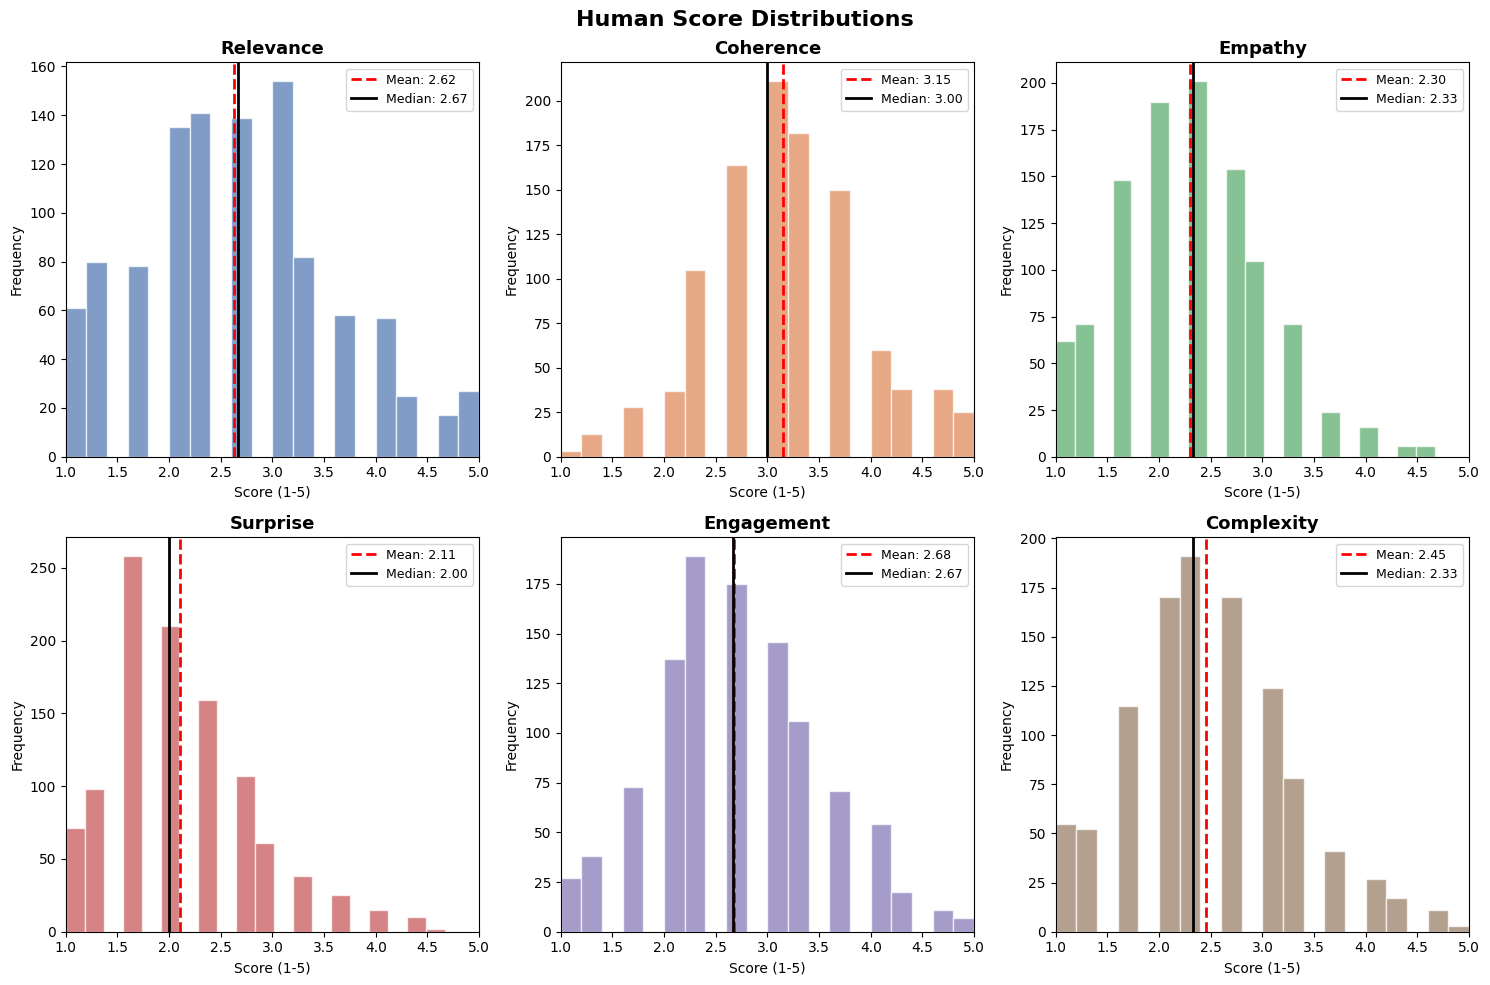

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Human Score Distributions', fontsize=16, fontweight='bold')

human_cols = ['human_relevance', 'human_coherence', 'human_empathy',
              'human_surprise', 'human_engagement', 'human_complexity']

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

for idx, (col, ax, color) in enumerate(zip(human_cols, axes.flatten(), colors)):
    metric = col.replace('human_', '').capitalize()

    # Get unique human scores per story (avoid duplicates)
    unique_scores = combined_df.drop_duplicates('story_id')[col]

    ax.hist(unique_scores, bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(unique_scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {unique_scores.mean():.2f}')
    ax.axvline(unique_scores.median(), color='black', linestyle='-',
               linewidth=2, label=f'Median: {unique_scores.median():.2f}')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.set_xlim(1, 5)

plt.tight_layout()
plt.savefig('human_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

**Highest-rated dimension**: Coherence (mean = 3.15, median = 3.00)
- Stories generally make logical sense and flow well
- Distribution is roughly bell-shaped and centered

**Lowest-rated dimension**: Surprise (mean = 2.11, median = 2.00)
- Most stories scored low on originality
- Strongly left-skewed—humans found few stories truly surprising
- This explains why Surprise was the hardest metric for LLMs to predict

**Score range usage**:
- Humans do NOT fully utilize the 1-5 scale
- Scores above 4.5 are very rare across all metrics
- This suggests humans apply strict evaluation standards—a "5" is reserved for exceptional quality

**Distribution shapes**:
- Coherence, Engagement, Relevance: roughly normal distributions
- Surprise, Empathy: left-skewed (most stories cluster at lower scores)
- Complexity: fairly uniform spread with slight right skew

> **Key insight**: Humans are tougher graders than the scale suggests. The theoretical maximum is 5.0, but practical maximum hovers around 4.7. LLMs will need to capture this calibration to align with human judgment.

---

  ---

### LLM vs Human Distributions

Next we will be Comparing score patterns between all models and humans.

> How do LLM scores compare to human ratings? Do models use the same range? Are they consistently higher or lower than humans?



/tmp/ipykernel_695/2260411613.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, patch_artist=True, labels=labels,
/tmp/ipykernel_695/2260411613.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, patch_artist=True, labels=labels,
/tmp/ipykernel_695/2260411613.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, patch_artist=True, labels=labels,
/tmp/ipykernel_695/2260411613.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be drop

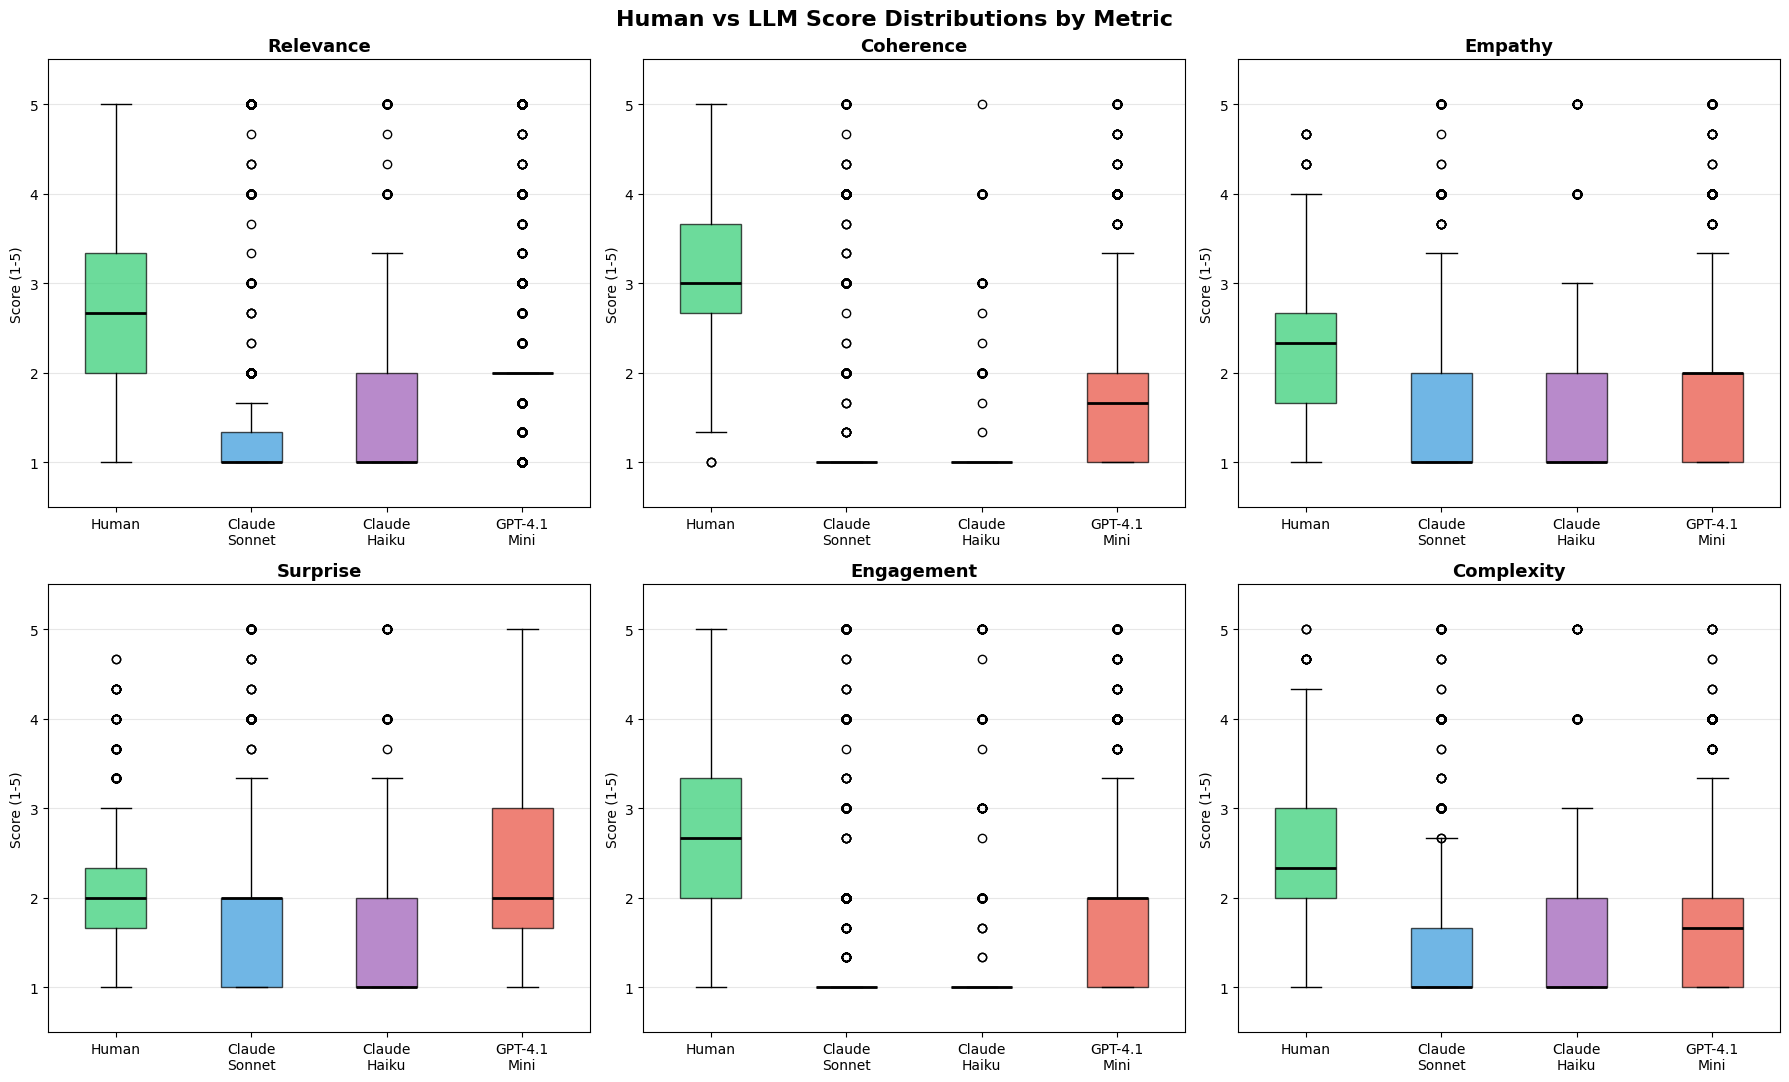

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Human vs LLM Score Distributions by Metric', fontsize=16, fontweight='bold')

metrics = ['relevance', 'coherence', 'empathy', 'surprise', 'engagement', 'complexity']

for idx, metric in enumerate(metrics):
    ax = axes.flatten()[idx]

    plot_data = []
    labels = []
    colors_box = []

    # Human scores (unique per story)
    human_scores = combined_df.drop_duplicates('story_id')[f'human_{metric}'].dropna()
    plot_data.append(human_scores)
    labels.append('Human')
    colors_box.append('#2ecc71')

    # Claude Sonnet
    sonnet = combined_df[combined_df['model_version'].str.contains('sonnet', case=False, na=False)][f'avg_{metric}'].dropna()
    plot_data.append(sonnet)
    labels.append('Claude\nSonnet')
    colors_box.append('#3498db')

    # Claude Haiku
    haiku = combined_df[combined_df['model_version'].str.contains('haiku', case=False, na=False)][f'avg_{metric}'].dropna()
    plot_data.append(haiku)
    labels.append('Claude\nHaiku')
    colors_box.append('#9b59b6')

    # GPT
    gpt = combined_df[combined_df['model'] == 'GPT'][f'avg_{metric}'].dropna()
    plot_data.append(gpt)
    labels.append('GPT-4.1\nMini')
    colors_box.append('#e74c3c')

    bp = ax.boxplot(plot_data, patch_artist=True, labels=labels,
                    medianprops=dict(color='black', linewidth=2))

    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(metric.capitalize(), fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (1-5)')
    ax.set_ylim(0.5, 5.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots_human_vs_llm.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution Comparison

**LLMs consistently score lower than humans** across all metrics:
- Human medians range from ~2.0 (Surprise) to ~3.0 (Coherence)
- LLMs rarely assign scores above 3.0, while humans regularly do

**LLM scores are much more compressed**:
- Human boxes (IQR) are wide, showing varied judgments across stories
- LLM boxes are narrow and low, especially for Claude models
- Claude Sonnet and Haiku show almost identical narrow ranges (minimal variation)
- GPT-4.1 Mini has slightly wider spread but still much tighter than humans

**Model differences**:
- **GPT-4.1 Mini** closest to human distributions (higher medians, more variation)
- **Claude Sonnet** very compressed, consistently low scores
- **Claude Haiku** nearly identical to Sonnet (justifies including Haiku Instruction in analysis)
- No model captures the full range of human judgment

> **Key insight**: LLMs are **conservative scorers**—they cluster most stories around 1.5-2.5 while humans spread across 2.0-4.0. This compression explains why accuracy is low even when correlation is moderate: LLMs can rank stories but don't calibrate to the human scoring scale.


  ---

### Scores by Technique

To understand whether prompting technique affect score patterns? We visualize average LLM scores across all 6 metrics for each technique, separated by model.

**This reveals**
- Whether certain techniques produce systematically higher/lower scores
- Which metrics are most affected by technique choice
- Differences in technique sensitivity between GPT and Claude


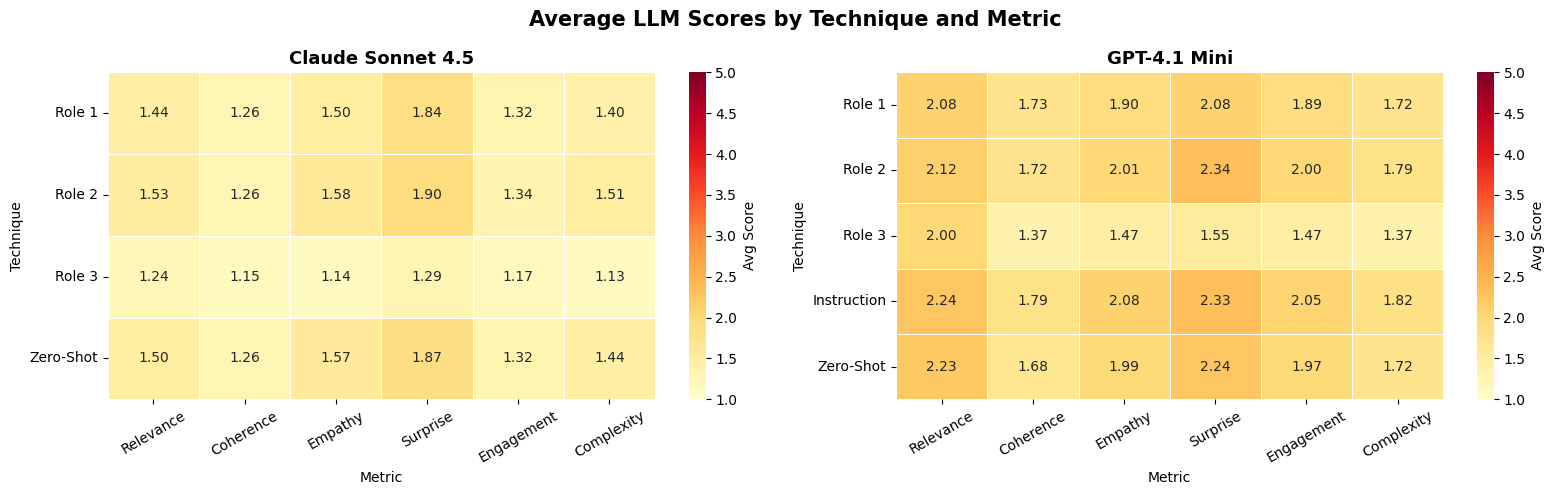

In [ ]:
metrics = ['relevance', 'coherence', 'empathy', 'surprise', 'engagement', 'complexity']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Average LLM Scores by Technique and Metric', fontsize=15, fontweight='bold')

# Claude: only techniques that exist
claude_df = combined_df[combined_df['model_version'].str.contains('sonnet', case=False, na=False)]
claude_techniques = ['role_1', 'role_2', 'role_3', 'zero_shot']
claude_labels     = ['Role 1', 'Role 2', 'Role 3', 'Zero-Shot']

# GPT: all 5 techniques
gpt_df = combined_df[combined_df['model'] == 'GPT']
gpt_techniques = ['role_1', 'role_2', 'role_3', 'instruction', 'zero_shot']
gpt_labels     = ['Role 1', 'Role 2', 'Role 3', 'Instruction', 'Zero-Shot']

configs = [
    (axes[0], 'Claude Sonnet 4.5', claude_df, claude_techniques, claude_labels),
    (axes[1], 'GPT-4.1 Mini',      gpt_df,    gpt_techniques,    gpt_labels),
]

for ax, title, df, techniques, labels in configs:
    matrix = []
    for tech in techniques:
        tech_df = df[df['technique'] == tech]
        row = [round(tech_df[f'avg_{m}'].mean(), 2) for m in metrics]
        matrix.append(row)

    matrix_df = pd.DataFrame(matrix, index=labels,
                             columns=[m.capitalize() for m in metrics])

    sns.heatmap(matrix_df, ax=ax, annot=True, fmt='.2f',
                cmap='YlOrRd', vmin=1, vmax=5,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Avg Score'})

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Technique')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('heatmap_scores_by_technique.png', dpi=150, bbox_inches='tight')
plt.show()



**Claude Sonnet 4.5** (all scores pale yellow, 1.13-1.90 range):
- Extremely compressed scoring—all cells look nearly identical
- Highest: Role 2 + Surprise (1.90), barely darker than the rest
- Lowest: Role 3 + Complexity (1.13), still pale yellow
- **Role 3 produces the lowest scores** across all metrics (lightest row)
- Minimal variation across techniques—prompting has little impact on Claude's scoring behavior

**GPT-4.1 Mini** (warmer oranges, 1.37-2.34 range):
- Much wider scoring range than Claude (nearly double)
- Highest: Role 2 + Surprise (2.34), clearly darker orange
- Lowest: Role 3 + Complexity/Coherence (1.37), matching Claude's pattern
- **Instruction technique** produces consistently higher scores (darker row overall)
- **Role 3 again produces the lowest scores** (lightest row)—the elaborate prompt hurts both models

**Cross-model patterns**:
- **Surprise scores highest** for both models (darkest column consistently)
- **Coherence scores lowest** for both models (lightest column consistently)
- This is the **opposite** of human ratings (humans rated Coherence high, Surprise low)
- **Role 3 universally struggles**—detailed prompts make models more conservative/critical
- **GPT shows more technique sensitivity** than Claude (more color variation)

> **Key insight**: LLMs invert human priorities—they find it easier to give high scores to Surprise (where humans were harsh) and harder to give high scores to Coherence (where humans were generous). Prompting technique matters more for GPT than Claude, but Role 3's elaborate persona hurts both models equally.

---

---

## 3.2 Correlation Analysis

Beyond exact scores, can LLMs at least rank stories correctly? A model might score a story as 3.2 instead of 4.0, but if it consistently rates better stories higher, it's still useful for filtering and selection.

We calculate two correlation measures for each model-technique-metric combination:
- **Spearman's ρ**: Checks if rankings match (does the LLM's top-rated story match the human top-rated story?)
- **Pearson's r**: Checks if the relationship is linear

**What we're looking for**:
- Positive correlations = LLM and humans agree on story quality order
- Values near 0 = rankings are essentially random
- Negative correlations = LLM systematically disagrees with humans (rare but alarming)


In [ ]:
from scipy import stats

metrics = ['relevance', 'coherence', 'empathy', 'surprise', 'engagement', 'complexity']

results = []

for _, grp in combined_df.groupby(['model', 'model_version', 'technique']):
    model      = grp['model'].iloc[0]
    version    = grp['model_version'].iloc[0]
    technique  = grp['technique'].iloc[0]

    for metric in metrics:
        human = grp[f'human_{metric}'].dropna()
        llm   = grp[f'avg_{metric}'].dropna()
        idx   = human.index.intersection(llm.index)

        if len(idx) < 10:
            continue

        h, l = human.loc[idx], llm.loc[idx]
        spearman_r, spearman_p = stats.spearmanr(h, l)
        pearson_r,  pearson_p  = stats.pearsonr(h, l)

        results.append({
            'model': model, 'version': version, 'technique': technique,
            'metric': metric,
            'spearman_r': round(spearman_r, 4),
            'spearman_p': round(spearman_p, 4),
            'pearson_r':  round(pearson_r,  4),
            'pearson_p':  round(pearson_p,  4),
        })

corr_df = pd.DataFrame(results)
print(corr_df.groupby('model')[['spearman_r','pearson_r']].mean().round(3))

        spearman_r  pearson_r
model                        
Claude      0.4190     0.4910
GPT         0.4470     0.5270



Both models show positive correlations—they rank stories in a similar order to humans:

- **Claude**: ρ = 0.419, r = 0.491
- **GPT**: ρ = 0.447, r = 0.527

GPT edges ahead by ~6%, but both show moderate agreement (around 0.4-0.5). Spearman values suggest models are better at relative comparisons than absolute scoring.

> Are some techniques or metrics stronger? Let's visualize the patterns.




### Correlation Heatmaps

Now let's break down the correlations by technique and metric. Which prompting approaches preserve human rankings best? Are some story dimensions easier for LLMs to judge than others?


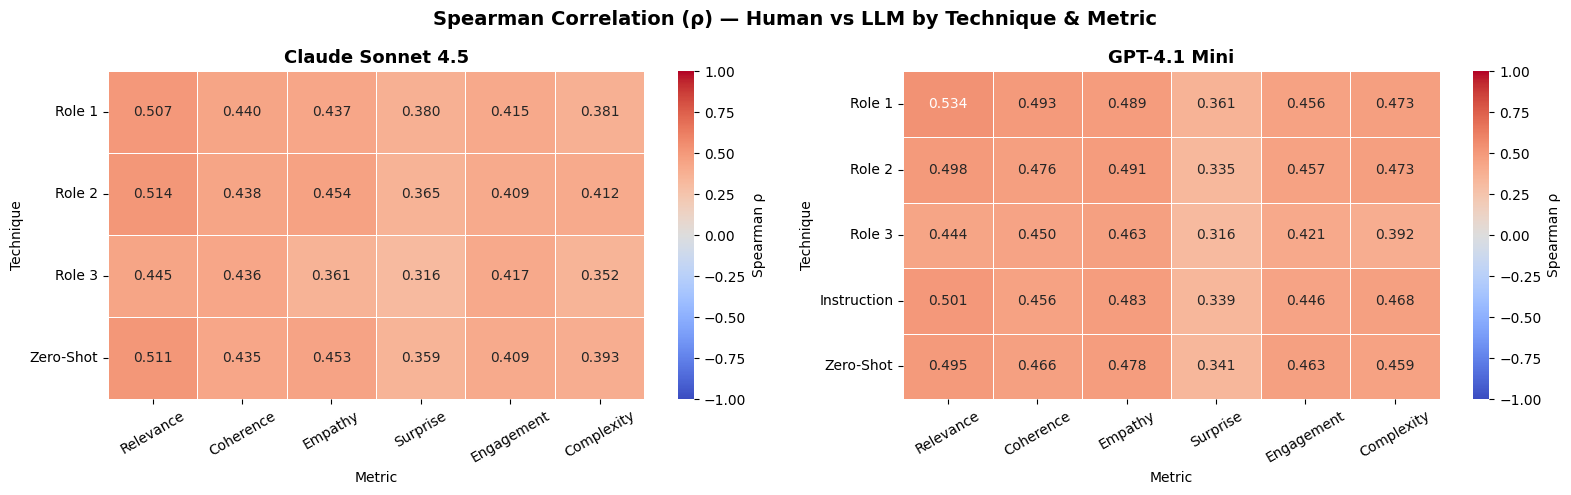

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Spearman Correlation (ρ) — Human vs LLM by Technique & Metric",
             fontsize=14, fontweight='bold')

technique_labels_map = {
    'role_1': 'Role 1', 'role_2': 'Role 2', 'role_3': 'Role 3',
    'instruction': 'Instruction', 'zero_shot': 'Zero-Shot'
}

claude_techs = ['role_1', 'role_2', 'role_3', 'zero_shot']
gpt_techs    = ['role_1', 'role_2', 'role_3', 'instruction', 'zero_shot']

configs = [
    (axes[0], 'Claude Sonnet 4.5', 'Claude', claude_techs),
    (axes[1], 'GPT-4.1 Mini',      'GPT',    gpt_techs),
]

for ax, title, model_name, techs in configs:
    matrix = []
    for tech in techs:
        row_df = corr_df[(corr_df['model'] == model_name) & (corr_df['technique'] == tech)]
        row = [row_df[row_df['metric'] == m]['spearman_r'].values[0]
               if len(row_df[row_df['metric'] == m]) > 0 else None
               for m in metrics]
        matrix.append(row)

    matrix_df = pd.DataFrame(
        matrix,
        index=[technique_labels_map[t] for t in techs],
        columns=[m.capitalize() for m in metrics]
    )

    sns.heatmap(matrix_df, ax=ax, annot=True, fmt='.3f',
                cmap='coolwarm', vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Spearman ρ'})

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Technique')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('heatmap_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### Pattern Analysis

Several clear patterns emerge from the heatmaps:

**Strongest correlations** (darkest cells):
- **Claude**: Zero-Shot + Relevance (ρ = 0.511), Role 2 + Relevance (ρ = 0.514), Role 1 + Relevance (ρ = 0.507)
- **GPT**: Role 1 + Relevance (ρ = 0.534), Instruction + Relevance (ρ = 0.501), Role 2 + Relevance (ρ = 0.498)

**Weakest correlations** (lightest cells):
- **Claude**: Role 3 + Surprise (ρ = 0.316), Role 3 + Complexity (ρ = 0.352), Role 2 + Surprise (ρ = 0.365)
- **GPT**: Role 3 + Surprise (ρ = 0.316), Role 2 + Surprise (ρ = 0.335), Instruction + Surprise (ρ = 0.339)

**Key observations**:
- **Relevance is easiest** for both models across all techniques (darkest column consistently)
- **Surprise is hardest** for both models across all techniques (lightest column consistently)
- **GPT correlations are uniformly higher** (warmer overall tone) than Claude across nearly all cells
- **Role 3 struggles** for both models—the elaborate "creative writing professor" persona actually hurts ranking ability
- **Technique variation matters less than metric choice**—switching from Relevance to Surprise drops correlation more than switching between techniques

> LLMs find it easier to judge whether a story addresses the prompt than whether it's surprising or original.

---

---

### Scatter Plots: Best vs Worst

To see what strong and weak correlations actually look like, let's visualize the two extremes: the best and worst configuration from our entire dataset.

The scatter plots show individual story scores with:
- **Perfect agreement line** (diagonal): where LLM and human scores match exactly
- **Regression line** (blue): actual trend in the data

The closer the regression line hugs the diagonal, the better the agreement.

Best:  GPT | role_1 | relevance | ρ=0.5337
Worst: GPT | role_3 | surprise | ρ=0.316


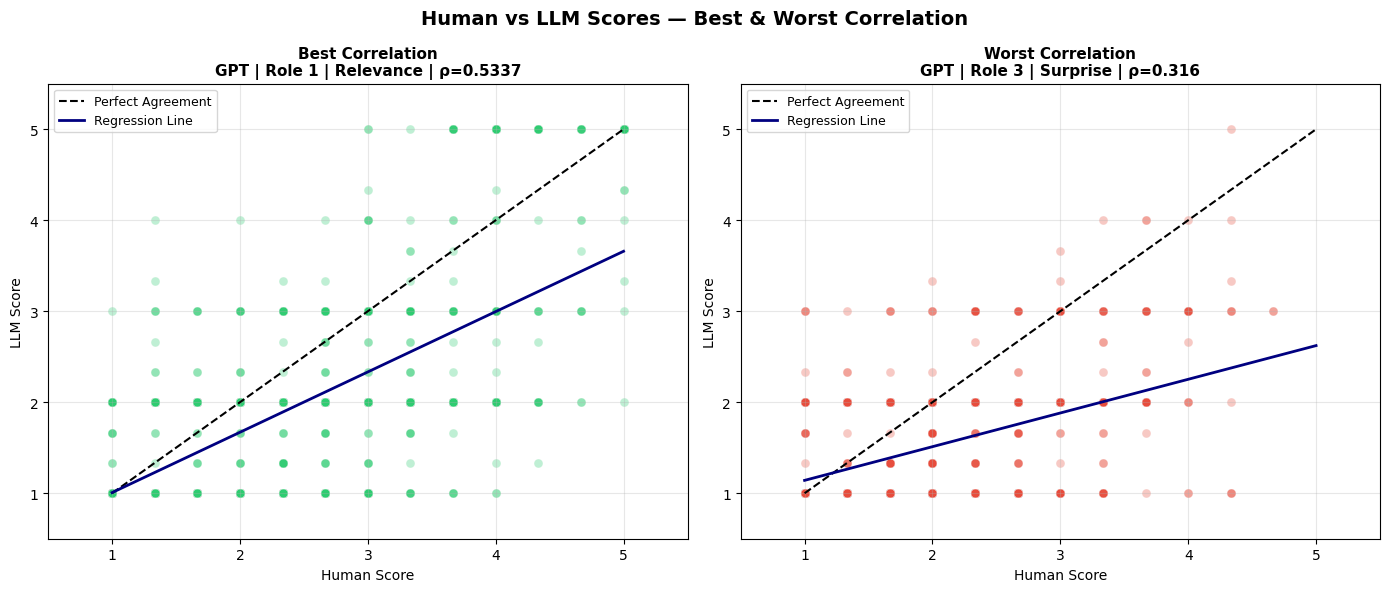

In [ ]:
# Find best and worst configurations
best  = corr_df.loc[corr_df['spearman_r'].idxmax()]
worst = corr_df.loc[corr_df['spearman_r'].idxmin()]

print(f"Best:  {best['model']} | {best['technique']} | {best['metric']} | ρ={best['spearman_r']}")
print(f"Worst: {worst['model']} | {worst['technique']} | {worst['metric']} | ρ={worst['spearman_r']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Human vs LLM Scores — Best & Worst Correlation', fontsize=14, fontweight='bold')

for ax, row, label, color in zip(
    axes,
    [best, worst],
    ['Best Correlation', 'Worst Correlation'],
    ['#2ecc71', '#e74c3c']
):
    subset = combined_df[
        (combined_df['model']     == row['model']) &
        (combined_df['technique'] == row['technique'])
    ]
    h = subset[f"human_{row['metric']}"].dropna()
    l = subset[f"avg_{row['metric']}"].dropna()
    idx = h.index.intersection(l.index)
    h, l = h.loc[idx], l.loc[idx]

    ax.scatter(h, l, alpha=0.3, color=color, edgecolors='white', linewidth=0.3, s=40)

    # Perfect agreement line
    ax.plot([1, 5], [1, 5], 'k--', linewidth=1.5, label='Perfect Agreement')

    # Regression line
    m_reg, b = np.polyfit(h, l, 1)
    x_line = np.linspace(1, 5, 100)
    ax.plot(x_line, m_reg * x_line + b, color='navy', linewidth=2, label='Regression Line')

    ax.set_title(
        f"{label}\n{row['model']} | {row['technique'].replace('_',' ').title()} | "
        f"{row['metric'].capitalize()} | ρ={row['spearman_r']}",
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Human Score')
    ax.set_ylabel('LLM Score')
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_best_worst.png', dpi=150, bbox_inches='tight')
plt.show()



- **All Spearman correlations are positive** (range: 0.31 – 0.53), confirming that both models rank stories in a similar order to humans, though not perfectly.
- **GPT-4.1 Mini achieves slightly higher correlations** than Claude Sonnet overall (avg ρ = 0.447 vs 0.419).

**Best vs Worst:**
- **Best**: GPT | Role 1 | Relevance (ρ = 0.534)
  - Regression line closely follows perfect agreement diagonal
  - Points cluster near the trend line
- **Worst**: GPT | Role 3 | Surprise (ρ = 0.316)
  - Widely scattered points, nearly flat regression line
  - LLM essentially guessing regardless of human judgment

**Story Metric Difficulty:**
- **Easiest**: Relevance (ρ = 0.49–0.53)—LLMs can judge if stories address the prompt
- **Hardest**: Surprise (ρ = 0.32–0.38)—LLMs struggle with originality and unexpectedness

**Technique Impact:**
- **Role 1 (simple "human annotator")** produces strongest correlations
- **Role 3 (elaborate "creative writing professor")** consistently worst
- Simple framing outperforms complex personas

> **Takeaway**: What you measure matters more than how you prompt. Metric choice drives ~0.20 correlation variation; technique choice drives only ~0.08.


---


# 4. Evaluation Metrics

Now that we've explored the data and understand how LLMs and humans differ in their scoring patterns, we need formal metrics to quantify alignment quality.

**What we're going to do in this section:**

We'll establish our evaluation framework by calculating three types of metrics:

1. **Error Metrics (4.1)** - Measure prediction distance using MAE and RMSE
2. **Classification Metrics (4.2)** - Treat scoring as classification and measure accuracy
3. **Visualize patterns** - Identify which techniques and metrics are hardest

This creates our measurement foundation for the model comparisons in Section 5.

---



## 4.1 Error Metrics

**What we're measuring here:**

Error metrics quantify how far LLM predictions deviate from human scores. We'll calculate MAE (Mean Absolute Error) and RMSE (Root Mean Square Error) for each model-technique-metric combination.

**Why both MAE and RMSE?**
- MAE treats all errors equally (easier to interpret)
- RMSE penalizes large errors more (reveals outlier problems)

**What to expect:** Lower values = better alignment with humans.

### Calculate MAE and RMSE

For each configuration (model × technique × metric), we compute:

**MAE (Mean Absolute Error):**
- Average of |Human - LLM|
- Interprets as: "on average, predictions are off by X points"
- Lower = better

**RMSE (Root Mean Square Error):**
- Square root of mean squared errors
- More sensitive to large mistakes
- Also lower = better

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

metrics = ['relevance', 'coherence', 'empathy', 'surprise', 'engagement', 'complexity']

error_results = []

for (model, technique), grp in combined_df.groupby(['model', 'technique']):
    for metric in metrics:
        human = grp[f'human_{metric}']
        llm = grp[f'avg_{metric}']

        mae = mean_absolute_error(human, llm)
        mse = mean_squared_error(human, llm)
        rmse = np.sqrt(mse)

        error_results.append({
            'model': model,
            'technique': technique,
            'metric': metric,
            'MAE': mae,
            'RMSE': rmse
        })

error_df = pd.DataFrame(error_results)
error_df.head()

,model,technique,metric,MAE,RMSE
0,Claude,instruction,relevance,1.2046,1.4316
1,Claude,instruction,coherence,1.9013,2.0278
2,Claude,instruction,empathy,0.8374,1.0226
3,Claude,instruction,surprise,0.8023,0.9941
4,Claude,instruction,engagement,1.4418,1.6151



The table shows MAE and RMSE for the first 5 configurations (Claude + Instruction technique across different metrics).

**Key observations from the sample:**
- **Surprise has lowest MAE** (0.80) - LLM scores closest to human on this metric for this configuration
- **Coherence has highest MAE** (1.90) - largest prediction errors
- **RMSE consistently higher than MAE** - confirms some large errors exist (RMSE penalizes outliers more)

**What this tells us:** Even within a single model-technique combination, prediction quality varies significantly by metric. Some story dimensions are inherently harder to evaluate than others.

**Next:** We'll aggregate these errors across all metrics to compare techniques and identify overall patterns.

---

### Error by Technique

**What we're doing:** Aggregate error across all 6 metrics for each technique to identify which prompting approaches minimize prediction error overall.

> The goal is to find which technique consistently produces the smallest distance from human scores.

### a. Average Error by Technique


Now let's step back from individual metrics and see which techniques perform best overall.

We'll average the MAE and RMSE across all 6 story dimensions (Relevance, Coherence, Empathy, Surprise, Engagement, Complexity) for each technique. This gives us a single error score per technique, making comparison straightforward.

> **Goal:** Identify which prompting approaches consistently minimize errors, regardless of which specific dimension we're evaluating.

---

In [ ]:
tech_error = error_df.groupby(['model', 'technique'])[['MAE', 'RMSE']].mean().reset_index()
tech_error

,model,technique,MAE,RMSE
0,Claude,instruction,1.1901,1.3737
1,Claude,role_1,1.2277,1.4082
2,Claude,role_2,1.1821,1.3652
3,Claude,role_3,1.3937,1.5615
4,Claude,zero_shot,1.2036,1.3852
5,GPT,instruction,0.8457,1.0322
6,GPT,role_1,0.8920,1.0802
7,GPT,role_2,0.8701,1.0552
8,GPT,role_3,1.0981,1.2753
9,GPT,zero_shot,0.8820,1.0676



The table above shows average MAE and RMSE across all 6 metrics for each model-technique combination.

**Key findings:**

**Claude performance:**
- **Best**: Role 2 (MAE = 1.18) and Zero-Shot (MAE = 1.20)
- **Worst**: Role 3 (MAE = 1.39) - the elaborate "creative writing professor" prompt produces highest errors
- All Claude techniques cluster in narrow range (1.18-1.39)

**GPT performance:**
- **Best**: Instruction (MAE = 0.85) and Role 2 (MAE = 0.87)
- **Worst**: Role 3 (MAE = 1.10) - same failure pattern as Claude
- GPT errors significantly lower than Claude across all techniques

**Cross-model patterns:**
- **GPT outperforms Claude** by ~0.3 MAE points (25-30% better)
- **Role 3 consistently worst** for both models - complex prompts hurt performance
- **Simple prompts work better**: Instruction, Role 1, Role 2, Zero-Shot all cluster together with similar (better) performance

**Next**: Visualize these differences with a bar chart for easier comparison.

---

#### Bar Plot

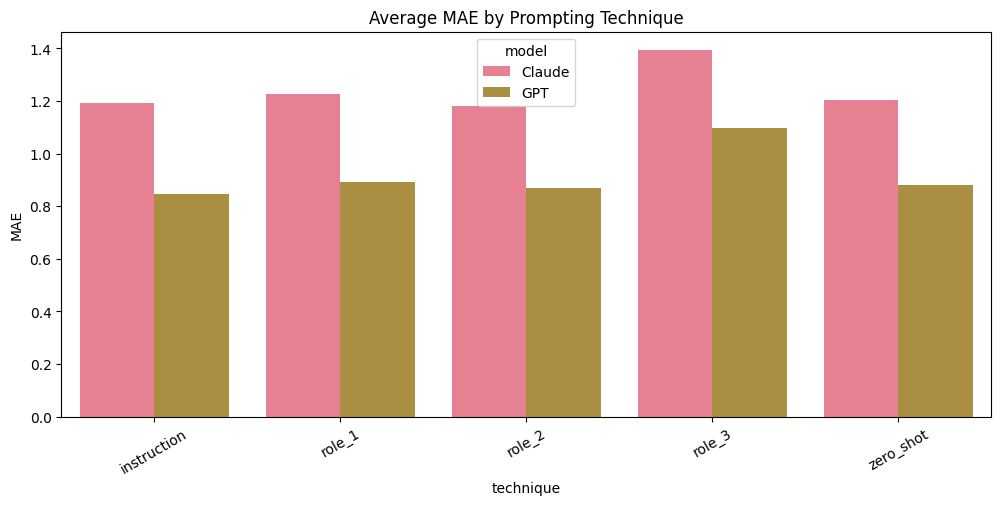

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.barplot(data=tech_error, x='technique', y='MAE', hue='model')
plt.title("Average MAE by Prompting Technique")
plt.xticks(rotation=30)
plt.show()


The bar chart confirms what the table showed, but makes the patterns easier to see:

**GPT advantage is clear:**
- GPT bars (gold) consistently shorter than Claude bars (pink) across all techniques
- The gap is roughly consistent—GPT maintains its ~0.3 point advantage regardless of prompting approach

**Role 3 stands out:**
- Tallest bars for both models—Role 3 produces the worst errors
- Claude's Role 3 bar reaches ~1.40, while even GPT struggles at ~1.10
- This elaborate "creative writing professor" prompt hurts both models

**Best techniques cluster together:**
- Instruction, Role 1, Role 2, and Zero-Shot all perform similarly
- For GPT: all cluster around 0.85-0.90 MAE
- For Claude: all cluster around 1.18-1.23 MAE
- Minimal differences between these four approaches

> **Key insight:** Prompting technique matters, but primarily to avoid catastrophic failures (Role 3). Among reasonable approaches, differences are small. Model choice (GPT vs Claude) has larger impact than prompt choice.

**Next:** Let's flip the analysis—instead of comparing techniques, let's compare which metrics are hardest to evaluate.

---

### b. Error by Metric

Now we're flipping the analysis by comparing metrics instead of techniques. Which story dimensions are inherently harder for LLMs to evaluate?

> **Goal:** Identify which evaluation dimensions (Relevance, Surprise, etc.) produce the largest prediction errors, revealing task difficulty.

In [ ]:
metric_error = error_df.groupby(['model', 'metric'])[['MAE', 'RMSE']].mean().reset_index()
metric_error = metric_error.sort_values('MAE', ascending=False)
metric_error

,model,metric,MAE,RMSE
0,Claude,coherence,1.9290,2.0525
6,GPT,coherence,1.5115,1.6595
3,Claude,engagement,1.4639,1.6307
4,Claude,relevance,1.2690,1.4880
1,Claude,complexity,1.1123,1.3020
9,GPT,engagement,0.9452,1.1445
2,Claude,empathy,0.9441,1.1259
7,GPT,complexity,0.8816,1.0711
10,GPT,relevance,0.7918,0.9937
8,GPT,empathy,0.7257,0.9127



The table ranks all 12 model-metric combinations from hardest (highest MAE) to easiest (lowest MAE).

**Hardest metrics (highest errors):**

1. **Coherence** - Claude MAE = 1.93, GPT MAE = 1.52
   - Hardest dimension for both models
   - Evaluating logical flow and narrative structure requires tracking cause-effect relationships and detecting plot holes across the entire story
   
2. **Engagement** - Claude MAE = 1.46, GPT MAE = 0.95
   - Second-hardest for Claude, moderate difficulty for GPT
   - Measuring how "captivating" a story is requires predicting emotional investment and reader interest—highly subjective qualities
   
3. **Relevance** - Claude MAE = 1.27, GPT MAE = 0.79
   - Mid-range difficulty
   - Determining prompt adherence requires understanding subtle thematic connections, not just keyword matching

**Easiest metrics (lowest errors):**

1. **Surprise** - GPT MAE = 0.65, Claude MAE = 0.72
   - Easiest for both models
   - Contrary to correlation analysis (where Surprise had weakest correlation)
   - Detecting unexpected plot twists or non-standard story elements is more concrete than evaluating flow
   
2. **Empathy** - GPT MAE = 0.73, Claude MAE = 0.94
   - Second-easiest
   - Identifying emotional depth and character feelings involves recognizing explicit emotional language and relational dynamics
   
3. **Complexity** - GPT MAE = 0.88, Claude MAE = 1.11
   - Relatively easy
   - Narrative richness can be approximated by counting subplots, character depth, and structural sophistication

> **What's interesting is that** Surprise has the **lowest MAE** (scores closest to human values) but had the **lowest correlation** in Section 3. This means:
- LLMs get close to the exact numeric values humans assign
- But they disagree on *which* stories are surprising (ranking disagreement)
- They're calibrated to the scale but judging different things

> **GPT achieves lower errors across** all 6 metrics—the advantage isn't metric-specific.

**Next:** Visualize these patterns with a bar chart.

---

#### Plot ranking

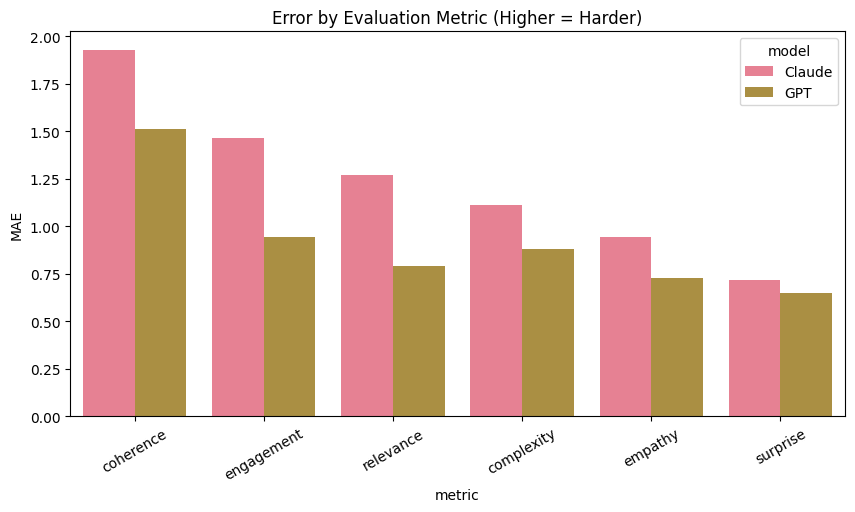

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=metric_error, x='metric', y='MAE', hue='model')
plt.title("Error by Evaluation Metric (Higher = Harder)")
plt.xticks(rotation=30)
plt.show()



The bar chart clearly shows the difficulty hierarchy from left (hardest) to right (easiest).

**Clear difficulty gradient:**
- **Coherence towers above everything else** - Claude nearly reaches 2.0 MAE, GPT at 1.5
- **Surprise barely registers** - both models under 0.75 MAE (shortest bars)
- **Claude forms a descending staircase pattern** - each metric progressively shorter from left to right
- **GPT shows less consistent ordering** - bars are more irregular, though still descending overall

**Consistent gap between models:**
- Claude bars (pink) consistently taller than GPT bars (gold) across all metrics
- The gap is proportionally larger for harder metrics (Coherence, Engagement)
- The gap narrows for easier metrics (Empathy, Surprise)
- GPT's advantage is most pronounced where the task is hardest

**The Coherence problem:**
- Both models struggle dramatically with this dimension
- Claude's error (1.93) is nearly 3× higher than for Surprise (0.72)
- Even GPT's best attempt (1.52) is still worse than its performance on any other metric
- Suggests evaluating narrative logic and flow is fundamentally harder than detecting emotional depth or unexpected elements

> **Key insight:** Task difficulty is metric-dependent, not model-dependent. Both models find the same dimensions hard and easy—GPT just performs better at every level. Claude's cleaner gradient suggests more consistent performance degradation across difficulty levels.

**Next:** Visualize the full error matrix with heatmaps showing technique-metric interactions.

---

### c. Error Heatmaps

**What we're doing:** Visualize the full error matrix (Technique × Metric) for both models using heatmaps.

> **Goal:** Spot patterns—do certain technique-metric combinations consistently fail? Are errors uniformly distributed or concentrated?

Darker colors = higher error = worse performance.

### Pivot for heatmap

In [ ]:
pivot_gpt = error_df[error_df['model']=='GPT'].pivot_table(
    index='technique',
    columns='metric',
    values='MAE'
)

pivot_claude = error_df[error_df['model']=='Claude'].pivot_table(
    index='technique',
    columns='metric',
    values='MAE'
)

###GPT Heatmap

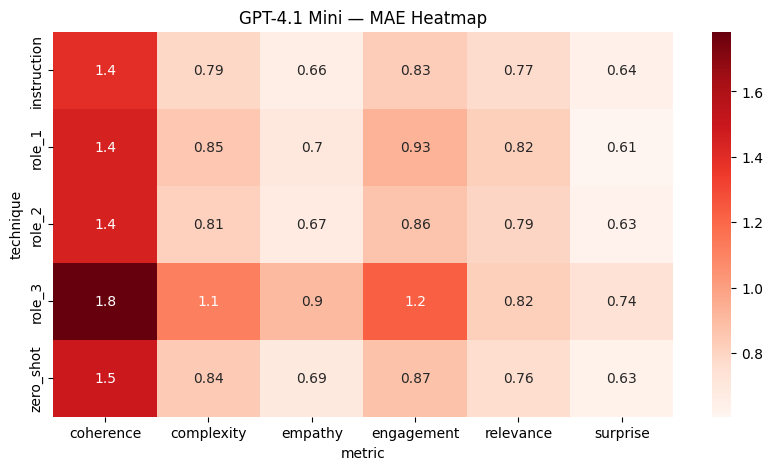

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(pivot_gpt, annot=True, cmap='Reds')
plt.title("GPT-4.1 Mini — MAE Heatmap")
plt.show()



The heatmap reveals which technique-metric combinations produce the highest errors (darker red = worse).

**Role 3 catastrophic failure (dark row):**
- Entire Role 3 row is noticeably darker than all other techniques
- Coherence reaches 1.8 MAE (darkest cell in entire heatmap)
- Engagement also problematic at 1.2 MAE
- Even the "easy" metrics (Empathy, Surprise) show elevated errors under Role 3

**Coherence column universally red:**
- Leftmost column (Coherence) entirely red across all techniques
- Every technique struggles with this metric (1.4-1.8 MAE)
- No prompting approach successfully evaluates narrative flow

**Surprise column universally pale:**
- Rightmost column (Surprise) lightest across all rows
- All techniques achieve low errors (0.61-0.74 MAE)
- Detecting unexpected elements is consistently easy

**Best performers cluster together:**
- Instruction, Role 1, Role 2, and Zero-Shot show similar pale patterns
- These four techniques are essentially interchangeable
- Minimal advantage to choosing one over another (except avoiding Role 3)

> **Key insight:** The heatmap shows two failure modes operating independently: (1) Role 3 hurts everything, and (2) Coherence is hard for everything. When they combine (Role 3 + Coherence), you get the worst performance possible (1.8 MAE).

**Next:** Claude's heatmap to see if patterns hold across models.

---

### Claude Heatmap

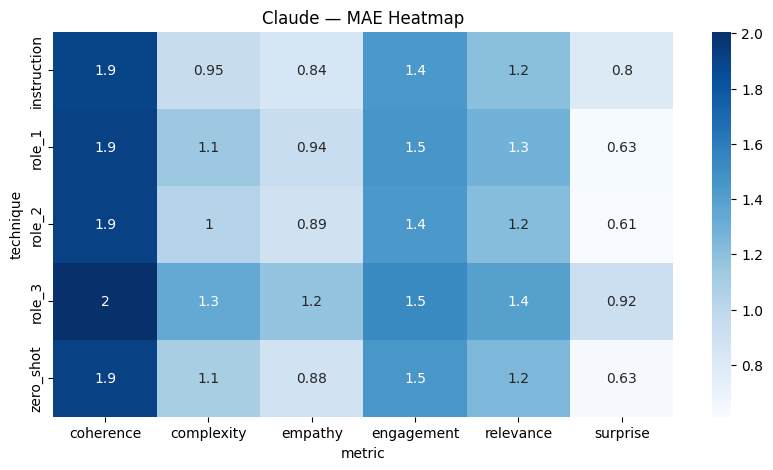

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(pivot_claude, annot=True, cmap='Blues')
plt.title("Claude — MAE Heatmap")
plt.show()



Claude's heatmap shows similar patterns to GPT but with uniformly higher errors (darker blues overall).

**Coherence column catastrophically dark:**
- Entire leftmost column (Coherence) in deep blue
- All techniques hit 1.9-2.0 MAE—nearly maximal errors
- Role 3 reaches 2.0 MAE (darkest cell in the entire heatmap)
- Claude fundamentally cannot evaluate narrative logic regardless of prompting

**Role 3 uniformly darker:**
- Fourth row (Role 3) noticeably darker across all metrics
- Even on "easy" metrics like Surprise (0.92), Role 3 underperforms other techniques (0.61-0.80)
- The elaborate prompt consistently degrades performance

**Surprise column universally light:**
- Rightmost column (Surprise) lightest across all techniques
- Claude finds this dimension easiest (0.61-0.92 MAE)
- Matches GPT's pattern—detecting unexpected elements is inherently easier

**Minimal technique differentiation:**
- Instruction, Role 1, Role 2, and Zero-Shot show nearly identical patterns
- All four cluster in similar color ranges for each metric
- Changing prompts between these four has negligible impact on Claude

**Comparing to GPT:**
- Claude's heatmap is **uniformly darker** than GPT's (blues vs. pale reds)
- Same patterns appear (Coherence hard, Surprise easy, Role 3 worst)
- But Claude operates at a consistently higher error level across the board
- The advantage of better prompting is smaller for Claude than for GPT

> **Key insight:** Claude and GPT share the same difficulty landscape—they struggle and succeed on identical dimensions. The difference is magnitude, not pattern. Role 3 and Coherence are universal failure modes across both models.

---

## 4.2 Classification Performance

**What we're doing in this subsection:**

So far we've measured continuous error (MAE/RMSE). Now we treat evaluation as **classification**—predicting the exact score category (1, 2, 3, 4, or 5).

We'll calculate:
1. **Exact-match accuracy** - How often does the LLM pick the exact right score?
2. **Cohen's Kappa** - Accuracy adjusted for chance agreement  
3. **Off-by-one accuracy** - More lenient metric (correct if within ±1)
4. **Confusion matrices** - Where do models make mistakes?

**Why this matters:** Classification metrics reveal whether models are **calibrated** to the 1-5 scale, not just good at relative ranking.

### Accuracy Metrics

*What we're calculating:**

Round LLM scores to nearest integer and compare with rounded human scores.

**Metrics:**
- **Exact match accuracy**: % of perfect predictions
- **Cohen's Kappa**: Agreement above random chance (adjusts for baseline)

**Baseline:** Random guessing on 5-point scale = 20% accuracy.

**What to expect:** Even good models may show low accuracy if they're poorly calibrated to the numeric scale.

### 1. Exact Match Accuracy + Cohen’s Kappa

In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

classification_results = []

for (model, technique), grp in combined_df.groupby(['model', 'technique']):
    for metric in metrics:

        human = grp[f'human_{metric}'].round()
        llm = grp[f'avg_{metric}'].round()

        acc = accuracy_score(human, llm)
        kappa = cohen_kappa_score(human, llm)

        classification_results.append({
            'model': model,
            'technique': technique,
            'metric': metric,
            'accuracy': acc,
            'kappa': kappa
        })

class_df = pd.DataFrame(classification_results)
class_df.head()

,model,technique,metric,accuracy,kappa
0,Claude,instruction,relevance,0.2078,0.0391
1,Claude,instruction,coherence,0.0380,-0.0113
2,Claude,instruction,empathy,0.3197,0.0548
3,Claude,instruction,surprise,0.3406,0.0714
4,Claude,instruction,engagement,0.1063,0.0202


### Classification Results

The table shows exact-match accuracy and Cohen's Kappa for the first 5 configurations (Claude + Instruction across metrics).

**Accuracy is extremely low:**
- **Surprise highest** at 34% accuracy (Claude correctly predicts exact score only 1 in 3 times)
- **Empathy** at 32% accuracy
- **Relevance** at 21% accuracy
- **Coherence catastrophically low** at 4% accuracy (nearly random guessing)
- **Engagement** at 11% accuracy

**Cohen's Kappa mostly near zero:**
- Most values between 0.02-0.07 (essentially random agreement)
- **Coherence shows negative Kappa** (-0.01) — worse than random chance
- Kappa adjusts for chance agreement, revealing that models aren't truly learning the scale

**This means that** even when LLMs get relatively close in absolute terms (MAE ~0.8-1.9), they rarely nail the exact integer score humans would assign. The models can rank stories but struggle to calibrate their continuous predictions to the discrete 1-5 scale.

> **Key observation:** High MAE on Coherence (1.9) translates to disastrous accuracy (4%). Low MAE on Surprise (0.8) translates to modest accuracy (34%). The relationship isn't linear—small MAE improvements don't guarantee proportional accuracy gains.

**Next:** Aggregate these results across all techniques to see overall patterns.

---

#### Overall Accuracy by Technique



Now we'll average the exact-match accuracy and Cohen's Kappa across all 6 metrics to see which techniques produce the most accurate predictions overall.

> **Goal:** Identify if any prompting approach can reliably predict exact human scores, or if calibration is a universal problem across all techniques.

---

In [ ]:
class_df.groupby(['model','technique'])[['accuracy','kappa']].mean()

accuracy   kappa
model  technique                    
Claude instruction    0.2154  0.0383
       role_1         0.2119  0.0413
       role_2         0.2334  0.0490
       role_3         0.1289 -0.0017
       zero_shot      0.2244  0.0457
GPT    instruction    0.3512  0.1066
       role_1         0.3297  0.0983
       role_2         0.3371  0.0926
       role_3         0.2347  0.0218
       zero_shot      0.3335  0.0967




**Claude's dismal accuracy:**
- **Best**: Role 2 at 23.3% accuracy (still gets 3 out of 4 predictions wrong)
- **Worst**: Role 3 at 12.9% accuracy (nearly random guessing on a 5-point scale)
- **Kappa near zero** across all techniques (0.00-0.05) — no meaningful agreement beyond chance
- Role 3 shows **negative Kappa** (-0.002) — actively worse than random

**GPT performs better but still struggles:**
- **Best**: Role 2 at 33.7% accuracy (still misses 2 out of 3)
- **Worst**: Role 3 at 23.5% accuracy (half of Claude's best)
- **Kappa slightly positive** (0.02-0.11) but still weak
- Roughly 10 percentage points better than Claude across the board

**Role 3 consistently worst:**
- Both models show lowest accuracy with Role 3
- GPT's Role 3 (23.5%) barely matches Claude's best technique (23.3%)
- The elaborate prompt sabotages exact-match performance

> **Key insight:** Even the best configuration (GPT + Role 2) only achieves 34% accuracy—meaning LLMs fail to predict the exact human score 66% of the time. Models can rank stories (moderate correlation) but can't nail the precise 1-5 category.

This suggests a **calibration problem**, not a ranking problem. LLMs understand relative quality but struggle to map it onto the discrete scoring scale.

**Next:** Check if off-by-one accuracy is more forgiving—maybe models are close even when not exact.

---

### 2. Off-by-One Accuracy

**What we're doing:** Instead of requiring exact matches, we'll accept predictions that are within ± 1 point of the human score.

**Why this matters:** If a human rates a story as 3 and the LLM says 4, that's close enough for many practical applications. This metric captures "roughly right" rather than "exactly right."

> **Goal:** See if models are directionally correct even when not perfectly calibrated.

In [ ]:
off_by_one_results = []

for (model, technique), grp in combined_df.groupby(['model', 'technique']):
    for metric in metrics:

        human = grp[f'human_{metric}']
        llm = grp[f'avg_{metric}']

        off_by_one = ((abs(human - llm) <= 1).mean())

        off_by_one_results.append({
            'model': model,
            'technique': technique,
            'metric': metric,
            'off_by_one_acc': off_by_one
        })

off_df = pd.DataFrame(off_by_one_results)
off_df.groupby(['model','technique'])['off_by_one_acc'].mean()

model   technique  
Claude  instruction   0.5220
        role_1        0.4913
        role_2        0.5194
        role_3        0.4018
        zero_shot     0.5066
GPT     instruction   0.7146
        role_1        0.6861
        role_2        0.6975
        role_3        0.5672
        zero_shot     0.6924
Name: off_by_one_acc, dtype: float64


Accuracy improved dramatically but remains far from perfect.

**Claude's performance:**
- **Best**: Instruction at 52.2% (roughly half of predictions within ±1)
- **Worst**: Role 3 at 40.2% (still misses 6 out of 10)
- Average around 49-52% for good techniques
- Role 3 drops ~10 percentage points below other approaches

**GPT's performance:**
- **Best**: Instruction at 71.5% (7 out of 10 predictions within ±1)
- **Worst**: Role 3 at 56.7% (still better than Claude's best)
- Average around 69-71% for good techniques
- Consistently 20 percentage points ahead of Claude

**Comparing exact vs off-by-one:**
- **Claude**: Jumps from ~21% exact to ~52% off-by-one (2.5× improvement)
- **GPT**: Jumps from ~33% exact to ~71% off-by-one (2.1× improvement)
- Most errors are small (off by 1 point) rather than catastrophic

**Role 3 pattern persists:**
- Still the worst performer even with lenient scoring
- GPT Role 3 (56.7%) matches Claude's best techniques (~52%)
- The elaborate prompt hurts both exact and approximate accuracy

> **Key insight:** Models are usually "close" even when not exact. The problem isn't wild guessing—it's fine-grained calibration. LLMs understand the general quality range but struggle to pin down the precise integer on the 1-5 scale.

**Next:** Compare exact vs off-by-one accuracy side-by-side to see the full picture.

---

#### Exact vs Off-by-One Comparison

Now we'll merge the exact-match and off-by-one accuracy tables side-by-side to see the full picture.

This shows how much accuracy improves when we accept "close enough" instead of demanding perfection.

---

In [ ]:
summary_acc = class_df.groupby(['model','technique'])['accuracy'].mean().reset_index()
summary_off = off_df.groupby(['model','technique'])['off_by_one_acc'].mean().reset_index()

merged = summary_acc.merge(summary_off, on=['model','technique'])

merged

,model,technique,accuracy,off_by_one_acc
0,Claude,instruction,0.2154,0.5220
1,Claude,role_1,0.2119,0.4913
2,Claude,role_2,0.2334,0.5194
3,Claude,role_3,0.1289,0.4018
4,Claude,zero_shot,0.2244,0.5066
5,GPT,instruction,0.3512,0.7146
6,GPT,role_1,0.3297,0.6861
7,GPT,role_2,0.3371,0.6975
8,GPT,role_3,0.2347,0.5672
9,GPT,zero_shot,0.3335,0.6924


#### Side-by-Side Comparison

The table reveals how much the accuracy metric improves when we allow ±1 tolerance.

**Improvement ratios:**
- **Claude**: 2.4-2.5× improvement across most techniques
  - Instruction: 21.5% → 52.2% (2.4× better)
  - Role 1: 21.2% → 49.1% (2.3× better)
  - Role 2: 23.3% → 51.9% (2.2× better)
  
- **GPT**: 2.0-2.4× improvement across techniques
  - Instruction: 35.1% → 71.5% (2.0× better)
  - Role 1: 33.0% → 68.6% (2.1× better)
  - Role 2: 33.7% → 69.8% (2.1× better)

**Role 3 anomaly:**
- **Claude Role 3**: 12.9% → 40.2% (3.1× improvement—largest jump)
- **GPT Role 3**: 23.5% → 56.7% (2.4× improvement)
- Role 3 errors are more evenly distributed (many off-by-1 mistakes), while other techniques either nail it or miss by more

> **Key pattern:**
Every technique roughly **doubles** in accuracy when we accept ±1 tolerance. This means:
> - About half of all errors are off-by-1 (recoverable with lenient scoring)
> - The other half are off-by-2+ (more serious calibration failures)


**Next:** Visualize where models make mistakes with confusion matrices.

---

### Confusion Matrices

**What we're doing:** Visualize exactly where models make mistakes using confusion matrices for the best and worst performing configurations.

**How to read the matrix:**
- **Rows** = Human scores (what the true rating was)
- **Columns** = LLM scores (what the model predicted)
- **Diagonal** (top-left to bottom-right) = correct predictions
- **Off-diagonal** = errors
- **Darker green** = more predictions

> **Goal:** Understand error patterns—do models systematically over-predict? Under-predict? Cluster around certain scores?

---

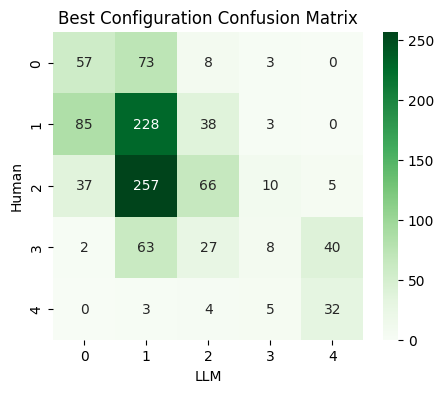

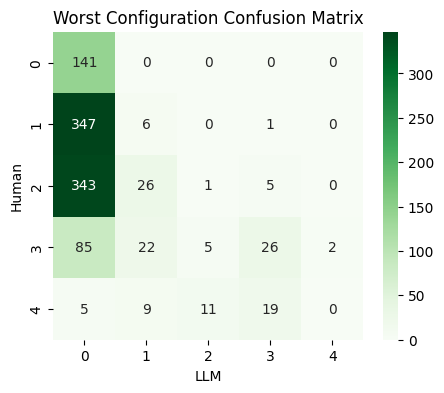

In [ ]:
from sklearn.metrics import confusion_matrix

best_cfg = class_df.groupby(['model','technique'])['accuracy'].mean().idxmax()
worst_cfg = class_df.groupby(['model','technique'])['accuracy'].mean().idxmin()

def plot_cm(model, technique, title):
    subset = combined_df[(combined_df['model']==model) & (combined_df['technique']==technique)]

    human = subset['human_relevance'].round()
    llm = subset['avg_relevance'].round()

    cm = confusion_matrix(human, llm, labels=[1,2,3,4,5])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(title)
    plt.xlabel("LLM")
    plt.ylabel("Human")
    plt.show()

plot_cm(*best_cfg, title="Best Configuration Confusion Matrix")
plot_cm(*worst_cfg, title="Worst Configuration Confusion Matrix")

# Confusion Matrix Analysis

### Best Configuration (Top): GPT + Instruction + Relevance

**Strong diagonal:**
- Darkest cells along the diagonal (228 at position [1,1], 257 at [2,1])
- Model frequently predicts the correct score or very close

**Error patterns:**
- Most errors cluster adjacent to diagonal (off by 1 point)
- Human 0 → LLM often predicts 1: Slight over-prediction on lowest scores
- Human 1 → LLM clusters at 1 (228 correct): Strongest performance
- Human 2 → LLM mostly predicts 1-2 (257+66): Good concentration
- Human 3 → LLM spreads across 1-4: More uncertainty at mid-range
- Human 4 → LLM correctly predicts 4 (32 out of 44): Decent high-score accuracy

**Systematic bias:**
- Model defaults to scores 0-2 (leftmost columns are darkest)
- Very few predictions at score 4 (rightmost column mostly empty)
- Conservative scoring—avoids extreme high ratings

---

### Worst Configuration (Bottom): Claude + Role 3 + Relevance

**Collapsed predictions:**
- Entire first column (LLM=0) is dark green—model predicts 0 for almost everything
- Virtually no predictions in other columns (all nearly empty)
- Diagonal barely visible—almost no correct predictions

**Catastrophic failure pattern:**
- Human 0 → LLM predicts 0 (141 correct): Only accurate for lowest scores
- Human 1 → LLM predicts 0 (347 errors!): Massive under-prediction
- Human 2 → LLM predicts 0 (343 errors!): Even worse under-prediction
- Human 3 → LLM predicts 0 (85 errors): Continues under-predicting
- Human 4 → LLM rarely predicts anything: Model essentially broken

**What went wrong:** Role 3 causes Claude to collapse onto a single prediction (score 0) for nearly all stories, regardless of actual quality. The elaborate "creative writing professor" prompt doesn't just reduce accuracy—it destroys the model's ability to differentiate between stories.

---

### Comparing Best vs Worst

- **Best**: Predictions spread across the diagonal with small errors
- **Worst**: Predictions collapse to a single column (all zeros)
- **Best**: Off-by-one errors dominate
- **Worst**: Off-by-3+ errors dominate (everything rated 0)

### Key Insight

The worst configuration isn't just "less accurate"—it's fundamentally broken. The model stops functioning as a classifier and defaults to a single output regardless of input. This is a qualitative failure, not just a quantitative one.

**Why Instruction outperforms Role-based prompts:** The simplest, most direct prompt (Instruction-based, 35.12% accuracy) achieves the highest exact-match accuracy across all configurations. This suggests that elaborate role-playing personas consume model capacity without adding value for structured evaluation tasks.

# 5. Model & Technique Evaluation

We've calculated individual performance metrics. Now we compare models and techniques systematically to answer:

**Three critical questions:**

1. **Which prompting technique produces the most accurate evaluations?** (Section 5.1)
2. **How do Claude and GPT compare head-to-head?** (Section 5.2)  
3. **Can we trust results across different Claude versions?** (Section 5.3)

**What we'll do:**

- Create composite scores combining MAE, accuracy, and correlation
- Rank all techniques objectively
- Test statistical significance of differences  
- Conduct head-to-head model comparisons
- Validate consistency across Claude model versions

> Understanding these comparisons reveals not just which approach works best, but *why* certain techniques succeed or fail; insights that extend beyond this specific task to LLM evaluation more broadly.

---

## 5.1 Technique Comparison


In this subsection, we compare all 5 prompting techniques to identify which one produces the most accurate story evaluations overall.

**The challenge:** We have 3 different performance metrics (MAE, accuracy, correlation), and techniques might excel on one metric while failing on another. Looking at each metric separately could give conflicting answers about which technique is "best."

**Our solution:** Create a composite score that combines all three metrics into a single unified ranking. This reveals which techniques consistently perform well across all evaluation criteria.

**Steps:**
1. Calculate average MAE, accuracy, and Spearman correlation for each technique
2. Normalize all metrics to 0-1 scale (so they're comparable)
3. Combine into composite score with equal weighting
4. Rank techniques by composite score
5. Test statistical significance of differences

> **Goal:** Declare an objective winner for each model based on balanced performance across all three metrics.
 ---

### a. Overall Technique Ranking

**What we're calculating:**

For each model-technique combination:
- Average MAE across all 6 metrics (lower is better)
- Average accuracy across all 6 metrics (higher is better)
- Average Spearman correlation across all 6 metrics (higher is better)

Then normalize these to 0-1 scale and average them into a single composite score.

In [ ]:
# Prepare data for technique comparison
technique_performance = []

for (model, technique), grp in combined_df.groupby(['model', 'technique']):
    # Calculate average MAE across all metrics
    mae_scores = []
    acc_scores = []
    corr_scores = []

    for metric in metrics:
        human = grp[f'human_{metric}']
        llm = grp[f'avg_{metric}']

        # MAE
        mae = abs(human - llm).mean()
        mae_scores.append(mae)

        # Accuracy
        acc = accuracy_score(human.round(), llm.round())
        acc_scores.append(acc)

        # Correlation
        corr = human.corr(llm, method='spearman')
        corr_scores.append(corr)

    technique_performance.append({
        'model': model,
        'technique': technique,
        'avg_mae': np.mean(mae_scores),
        'avg_accuracy': np.mean(acc_scores),
        'avg_spearman': np.mean(corr_scores),
        'n_stories': len(grp)
    })

technique_df = pd.DataFrame(technique_performance)

# Create composite score (lower MAE is better, higher accuracy and correlation are better)
# Normalize each metric to 0-1 scale
technique_df['mae_norm'] = 1 - (technique_df['avg_mae'] - technique_df['avg_mae'].min()) / (technique_df['avg_mae'].max() - technique_df['avg_mae'].min())
technique_df['acc_norm'] = (technique_df['avg_accuracy'] - technique_df['avg_accuracy'].min()) / (technique_df['avg_accuracy'].max() - technique_df['avg_accuracy'].min())
technique_df['corr_norm'] = (technique_df['avg_spearman'] - technique_df['avg_spearman'].min()) / (technique_df['avg_spearman'].max() - technique_df['avg_spearman'].min())

# Composite score (equal weighting)
technique_df['composite_score'] = (technique_df['mae_norm'] + technique_df['acc_norm'] + technique_df['corr_norm']) / 3

# Add rank
technique_df['rank'] = technique_df.groupby('model')['composite_score'].rank(ascending=False)

# Display rankings
print("=== TECHNIQUE RANKINGS ===\n")
print("GPT-4.1 Mini:")
gpt_rank = technique_df[technique_df['model']=='GPT'].sort_values('rank')[['technique', 'avg_mae', 'avg_accuracy', 'avg_spearman', 'composite_score', 'rank']]
print(gpt_rank.to_string(index=False))

print("\n\nClaude:")
claude_rank = technique_df[technique_df['model']=='Claude'].sort_values('rank')[['technique', 'avg_mae', 'avg_accuracy', 'avg_spearman', 'composite_score', 'rank']]
print(claude_rank.to_string(index=False))

=== TECHNIQUE RANKINGS ===

GPT-4.1 Mini:
  technique  avg_mae  avg_accuracy  avg_spearman  composite_score   rank
     role_1   0.8920        0.3297        0.4674           0.9396 1.0000
instruction   0.8457        0.3512        0.4486           0.9212 2.0000
     role_2   0.8701        0.3371        0.4548           0.9114 3.0000
  zero_shot   0.8820        0.3335        0.4505           0.8806 4.0000
     role_3   1.0981        0.2347        0.4142           0.4488 5.0000


Claude:
  technique  avg_mae  avg_accuracy  avg_spearman  composite_score   rank
     role_2   1.1821        0.2334        0.4320           0.4705 1.0000
  zero_shot   1.2036        0.2244        0.4266           0.4212 2.0000
instruction   1.1901        0.2154        0.4202           0.3888 3.0000
     role_1   1.2277        0.2119        0.4267           0.3882 4.0000
     role_3   1.3937        0.1289        0.3879           0.0000 5.0000


#### Why Simpler Prompts Win?

The rankings reveal a striking pattern: **simpler prompts consistently outperform complex ones**.

**GPT-4.1 Mini:**
- Best: Role 1 (Human Annotator, 0.940 composite score)
- Worst: Role 3 (Creative Writing Professor, 0.450)
- **52% performance drop** from adding "expertise"

**Why does added expertise hurt?** Three factors likely contribute:

1. **Cognitive overhead**: Elaborate personas consume model capacity on role-playing rather than task execution
2. **Response verbosity**: The "professor" role triggers hedging and qualifications that interfere with clean numerical judgments  
3. **Over-complexity**: Detailed expertise prompts activate overly nuanced reasoning that introduces noise instead of signal

**Claude's fundamental ceiling:**
- Best technique: Role 2 (0.471)
- Claude's winner barely reaches **half** of GPT's performance (0.940)
- All techniques cluster in narrow band (0.39-0.47)
- Suggests a **fundamental capability ceiling** rather than a prompting problem

**Cross-model pattern:**
Role 3 catastrophically fails for **both** models, confirming this isn't model-specific—elaborate prompts universally degrade performance on structured evaluation tasks.

> **Key insight:** When designing prompts for structured evaluation, **clarity trumps creativity**. Simple, direct instructions outperform elaborate role-playing consistently.

**Next:** Visualize these performance differences to see the gaps clearly.

---

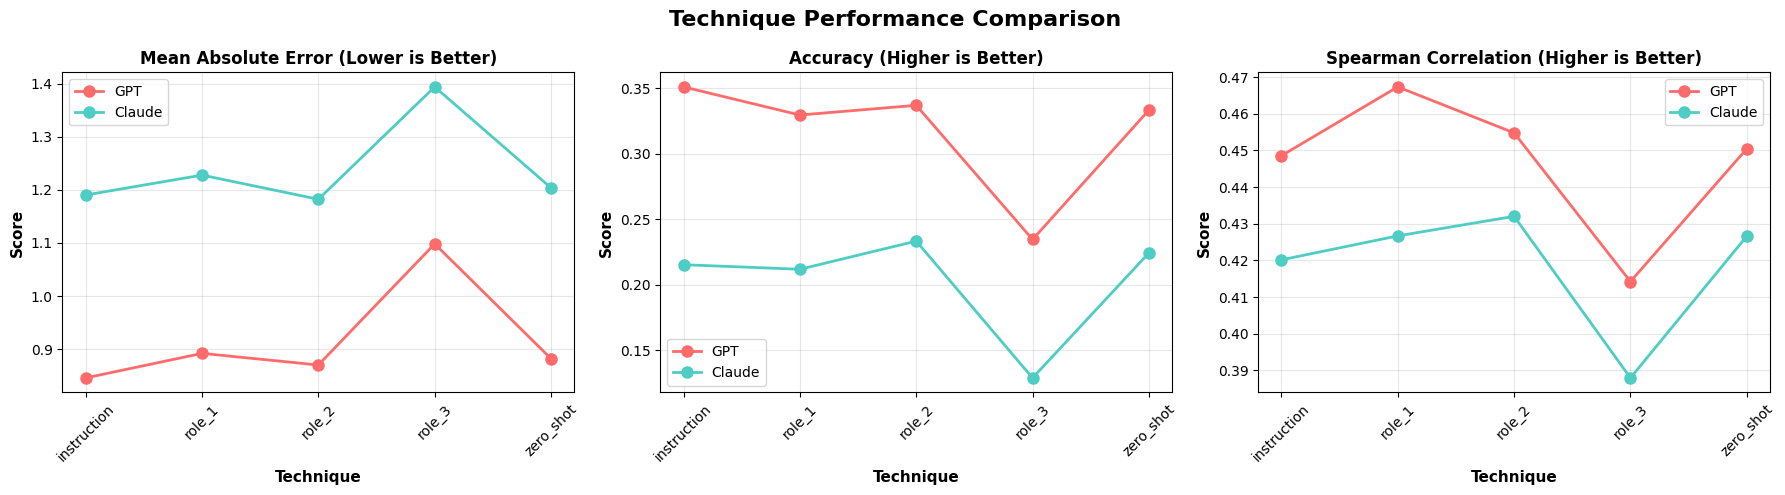

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Technique Performance Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['avg_mae', 'avg_accuracy', 'avg_spearman']
titles = ['Mean Absolute Error (Lower is Better)', 'Accuracy (Higher is Better)', 'Spearman Correlation (Higher is Better)']
colors_palette = {'GPT': '#FF6B6B', 'Claude': '#4ECDC4'}

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for model in ['GPT', 'Claude']:
        data = technique_df[technique_df['model']==model].sort_values('technique')
        ax.plot(data['technique'], data[metric], marker='o', linewidth=2,
                markersize=8, label=model, color=colors_palette[model])

    ax.set_xlabel('Technique', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('technique_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Visual Performance Comparison

The three-panel plot reveals two main findings about model and technique effects.

**Finding 1: GPT consistently outperforms Claude**
- GPT's line (red) stays above Claude's (teal) across all three metrics
- This is a **stable advantage**, not a trade-off—GPT wins simultaneously on accuracy, correlation, and MAE
- The gap remains roughly constant across techniques (both lines parallel)
- Better prompting doesn't close the model capability gap

**Finding 2: Role 3 is a universal failure mode**
- Both models show sharp deterioration at Role 3 (rightmost point on each panel)
- **MAE panel**: Both lines spike upward (worse errors)
- **Accuracy panel**: Both lines drop sharply (fewer correct predictions)
- **Correlation panel**: Both lines dip (weaker ranking agreement)
- **Claude is hit harder**: The spike/drop is more severe for Claude across all metrics

**Minimal interaction between model and technique:**
- The two curves remain **largely parallel** throughout
- What helps GPT also helps Claude (and vice versa)
- What hurts GPT also hurts Claude (Role 3 breaks both)
- This means: prompt optimization improves performance but **does not eliminate inherent differences between models**


---

### Statistical Significance
To confirm that observed differences are real rather than random variation, we test all pairwise technique comparisons using the Wilcoxon signed-rank test.

In [ ]:
from scipy.stats import wilcoxon

# Statistical significance testing between techniques
# Focus on GPT (cleanest comparison - same model version across all techniques)
print("\n=== STATISTICAL SIGNIFICANCE TESTS ===")
print("Pairwise Wilcoxon Signed-Rank Tests for GPT Techniques\n")

gpt_techniques = technique_df[technique_df['model']=='GPT']['technique'].tolist()
significance_results = []

for i, tech1 in enumerate(gpt_techniques):
    for tech2 in gpt_techniques[i+1:]:
        # Get error distributions for both techniques
        grp1 = combined_df[(combined_df['model']=='GPT') & (combined_df['technique']==tech1)]
        grp2 = combined_df[(combined_df['model']=='GPT') & (combined_df['technique']==tech2)]

        # Calculate absolute errors across all metrics
        errors1 = []
        errors2 = []

        for metric in metrics:
            err1 = abs(grp1[f'human_{metric}'] - grp1[f'avg_{metric}'])
            err2 = abs(grp2[f'human_{metric}'] - grp2[f'avg_{metric}'])
            errors1.extend(err1.values)
            errors2.extend(err2.values)

        # Perform Wilcoxon signed-rank test
        stat, p_value = wilcoxon(errors1, errors2)

        # Determine significance level
        if p_value < 0.001:
            significance = "p < 0.001"
        elif p_value < 0.01:
            significance = "p < 0.01"
        elif p_value < 0.05:
            significance = "p < 0.05"
        else:
            significance = "not significant"

        # Store results
        significance_results.append({
            'technique_1': tech1,
            'technique_2': tech2,
            'statistic': stat,
            'p_value': p_value,
            'significant': 'Yes' if p_value < 0.05 else 'No'
        })

        # Display results
        print(f"{tech1} vs {tech2}:")
        print(f"  p-value = {p_value:.4f} ({significance})")

# Create summary DataFrame
sig_df = pd.DataFrame(significance_results)

print("\n=== SUMMARY TABLE ===")
print(sig_df.to_string(index=False))


=== STATISTICAL SIGNIFICANCE TESTS ===
Pairwise Wilcoxon Signed-Rank Tests for GPT Techniques

instruction vs role_1:
  p-value = 0.0000 (p < 0.001)
instruction vs role_2:
  p-value = 0.0000 (p < 0.001)
instruction vs role_3:
  p-value = 0.0000 (p < 0.001)
instruction vs zero_shot:
  p-value = 0.0000 (p < 0.001)
role_1 vs role_2:
  p-value = 0.0000 (p < 0.001)
role_1 vs role_3:
  p-value = 0.0000 (p < 0.001)
role_1 vs zero_shot:
  p-value = 0.0126 (p < 0.05)
role_2 vs role_3:
  p-value = 0.0000 (p < 0.001)
role_2 vs zero_shot:
  p-value = 0.0034 (p < 0.01)
role_3 vs zero_shot:
  p-value = 0.0000 (p < 0.001)

=== SUMMARY TABLE ===
technique_1 technique_2    statistic  p_value significant
instruction      role_1  499396.5000   0.0000         Yes
instruction      role_2  403227.5000   0.0000         Yes
instruction      role_3 1376090.5000   0.0000         Yes
instruction   zero_shot  343386.5000   0.0000         Yes
     role_1      role_2  525125.5000   0.0000         Yes
     role_1  

#### Statistical Significance Results

The Wilcoxon signed-rank tests confirm that all pairwise differences between techniques are statistically significant.

**All comparisons are significant:**
- **Every single comparison** shows "Yes" in the significant column
- **9 out of 10 comparisons** have p < 0.001 (extremely significant)
- **1 comparison** has p < 0.05 (Role 1 vs Zero-Shot, p = 0.0126)

**Strongest significance (p < 0.001):**
- **Any technique vs Role 3**: Instruction vs Role 3, Role 1 vs Role 3, Role 2 vs Role 3, Zero-Shot vs Role 3
  - Role 3 is so catastrophically bad that the difference is undeniable
- **Instruction vs other techniques**: Instruction vs Role 1, Role 2, Zero-Shot
  - Instruction's advantage is statistically robust
- **Role 1 vs Role 2**: Clear difference despite similar composite scores
- **Role 2 vs Role 3 and Zero-Shot**: Distinct performance tiers

**Moderate significance (p < 0.05):**
- **Role 1 vs Zero-Shot** (p = 0.0126): Smallest but still significant difference
- **Role 2 vs Zero-Shot** (p = 0.0034): Clear separation
- These represent more subtle performance differences between good techniques

**What this means:**

**Technique choice matters statistically:** Even small differences in composite scores (e.g., 0.940 vs 0.881 for Role 1 vs Zero-Shot) are real effects, not random noise.

**Role 3's failure is undeniable:** The p < 0.001 significance level for all Role 3 comparisons confirms it's a consistent, extreme outlier—not a fluke or measurement error.

**No "ties":** We can confidently rank all 5 techniques without worrying that differences are just sampling variation. Every technique occupies a distinct performance tier.

**Practical implication:** These aren't just numerical differences—they're **statistically robust** patterns that will replicate. Prompt engineering has measurable, significant impact on LLM evaluation quality.

> **Key insight:** All pairwise differences are significant, confirming that prompting technique is a **major driver of performance variation**, not a minor tuning parameter. The consistency of p < 0.001 results (especially for Role 3) reinforces that some techniques produce extremely large and highly replicable effects.

---

### Technique Summary Table


In [ ]:
# Create comprehensive summary tables
print("\n=== TECHNIQUE SUMMARY TABLES ===\n")

# GPT Summary
print("GPT-4.1 Mini Performance by Technique:")
gpt_summary = technique_df[technique_df['model']=='GPT'][['technique', 'avg_mae', 'avg_accuracy', 'avg_spearman', 'rank']].sort_values('rank')
gpt_summary_styled = gpt_summary.copy()
gpt_summary_styled['avg_mae'] = gpt_summary_styled['avg_mae'].apply(lambda x: f"{x:.4f}")
gpt_summary_styled['avg_accuracy'] = gpt_summary_styled['avg_accuracy'].apply(lambda x: f"{x:.4f}")
gpt_summary_styled['avg_spearman'] = gpt_summary_styled['avg_spearman'].apply(lambda x: f"{x:.4f}")
gpt_summary_styled['rank'] = gpt_summary_styled['rank'].astype(int)
print(gpt_summary_styled.to_string(index=False))

print("\n\nClaude Performance by Technique:")
claude_summary = technique_df[technique_df['model']=='Claude'][['technique', 'avg_mae', 'avg_accuracy', 'avg_spearman', 'rank']].sort_values('rank')
claude_summary_styled = claude_summary.copy()
claude_summary_styled['avg_mae'] = claude_summary_styled['avg_mae'].apply(lambda x: f"{x:.4f}")
claude_summary_styled['avg_accuracy'] = claude_summary_styled['avg_accuracy'].apply(lambda x: f"{x:.4f}")
claude_summary_styled['avg_spearman'] = claude_summary_styled['avg_spearman'].apply(lambda x: f"{x:.4f}")
claude_summary_styled['rank'] = claude_summary_styled['rank'].astype(int)
print(claude_summary_styled.to_string(index=False))


=== TECHNIQUE SUMMARY TABLES ===

GPT-4.1 Mini Performance by Technique:
  technique avg_mae avg_accuracy avg_spearman  rank
     role_1  0.8920       0.3297       0.4674     1
instruction  0.8457       0.3512       0.4486     2
     role_2  0.8701       0.3371       0.4548     3
  zero_shot  0.8820       0.3335       0.4505     4
     role_3  1.0981       0.2347       0.4142     5


Claude Performance by Technique:
  technique avg_mae avg_accuracy avg_spearman  rank
     role_2  1.1821       0.2334       0.4320     1
  zero_shot  1.2036       0.2244       0.4266     2
instruction  1.1901       0.2154       0.4202     3
     role_1  1.2277       0.2119       0.4267     4
     role_3  1.3937       0.1289       0.3879     5


#### Technique Summary Tables

Clean side-by-side comparison of all techniques for each model, ranked by composite score.

**GPT-4.1 Mini:**
- **Clear winner**: Role 1 (lowest MAE, best correlation, ranked #1)
- **Top tier cluster**: Role 1, Instruction, Role 2 (ranks 1-3)
  - All achieve MAE < 0.90, accuracy > 33%, correlation > 0.44
  - Minimal practical differences between these three
- **Acceptable**: Zero-Shot (rank 4)
  - Still good performance, slightly behind top tier
- **Complete failure**: Role 3 (rank 5)
  - MAE spikes to 1.10 (26% worse than winner)
  - Accuracy drops to 23.5% (29% worse than winner)
  - Correlation weakest at 0.414

**Claude:**
- **Best available**: Role 2 (MAE 1.18, accuracy 23%, correlation 0.432)
- **Tight clustering**: Ranks 1-4 span narrow range
  - Role 2, Zero-Shot, Instruction, Role 1 all perform similarly
  - MAE varies only 1.18-1.23 (4% range)
  - Accuracy varies only 21-23% (minimal difference)
  - Correlation varies only 0.420-0.433 (3% range)
- **Universal failure**: Role 3 (rank 5)
  - MAE jumps to 1.39 (18% worse than winner)
  - Accuracy collapses to 12.9% (45% worse than winner)
  - Correlation drops to 0.388

**Cross-model observations:**

**Claude's best doesn't match GPT's worst:** Claude's top technique (Role 2, MAE 1.18) performs worse than GPT's second-worst technique (Zero-Shot, MAE 0.88). No prompting strategy overcomes the fundamental capability gap.

**Both models agree on Role 3:** Last place for both models. The elaborate prompt is universally detrimental.

**Technique sensitivity differs:** GPT shows 26% performance range between best and worst (0.85-1.10 MAE). Claude shows 18% range (1.18-1.39 MAE). GPT is more sensitive to prompting choices.

**Correlation is most stable:** Spearman correlation varies least across techniques for both models (GPT: 0.41-0.47, Claude: 0.39-0.43). Ranking ability is more robust to prompt changes than exact scoring.

> **Key insight:** For GPT, technique choice matters—pick Role 1, Instruction, or Role 2 and avoid Role 3. For Claude, technique choice matters less (except avoiding Role 3)—performance is more constrained by model capabilities than prompting strategy.

---

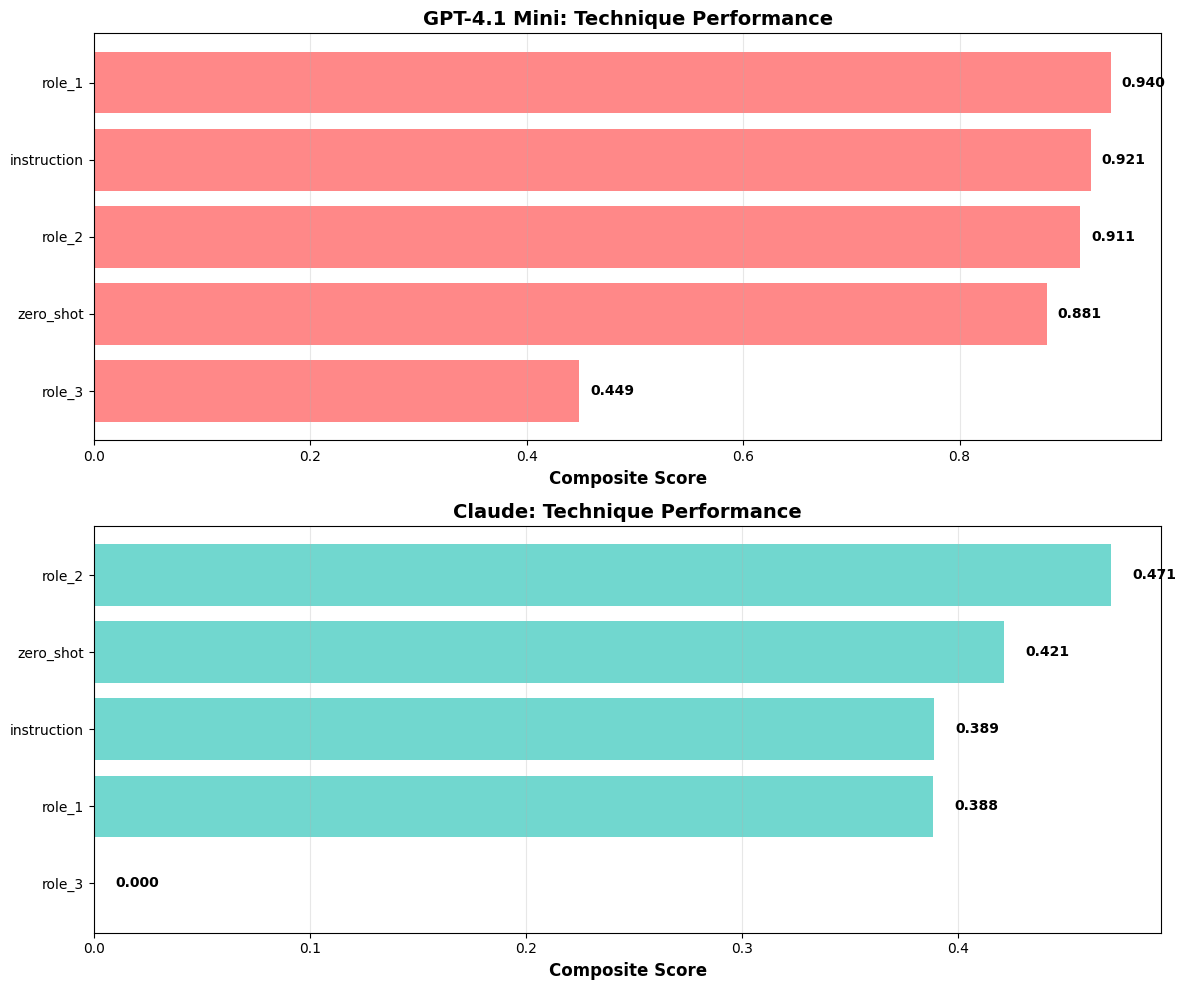

In [ ]:
# Visualization: Bar chart comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# GPT
ax = axes[0]
gpt_data = technique_df[technique_df['model']=='GPT'].sort_values('composite_score', ascending=True)
bars = ax.barh(gpt_data['technique'], gpt_data['composite_score'], color='#FF6B6B', alpha=0.8)
ax.set_xlabel('Composite Score', fontsize=12, fontweight='bold')
ax.set_title('GPT-4.1 Mini: Technique Performance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, gpt_data['composite_score'])):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontweight='bold')

# Claude
ax = axes[1]
claude_data = technique_df[technique_df['model']=='Claude'].sort_values('composite_score', ascending=True)
bars = ax.barh(claude_data['technique'], claude_data['composite_score'], color='#4ECDC4', alpha=0.8)
ax.set_xlabel('Composite Score', fontsize=12, fontweight='bold')
ax.set_title('Claude: Technique Performance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, claude_data['composite_score'])):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('technique_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

### Bar Chart Summary

The bar charts clearly reveal how prompting techniques affect performance across the two models.

**GPT-4.1 Mini pattern:**
- **High-performing cluster**: Role 1, Instruction, and Role 2 perform nearly identically (0.911-0.940)
- **Acceptable fallback**: Zero-Shot slightly lower but still competitive (0.881)
- **Catastrophic failure**: Role 3 collapses to 0.449—a **52% drop** from the winner
- This isn't gradual degradation—it's a clear failure mode

**Claude pattern:**
- **Tight clustering**: All techniques (except Role 3) compressed in narrow range (0.388-0.471)
- **Limited differentiation**: Changing prompts yields minimal improvement
- **Role 3 complete collapse**: Drops to 0.000 composite score
- Performance appears **constrained by model capability** rather than prompting strategy

**Cross-model gap:**
- **Claude's best** (Role 2, 0.471) **doesn't reach half** of GPT's best (Role 1, 0.940)
- Claude's winner falls below GPT's worst effective technique (Zero-Shot, 0.881)
- Indicates a **substantial baseline capability difference** between models
- No amount of prompt engineering bridges this gap

> **Key Insight:**

> For **GPT-4.1 Mini**, prompting technique is a **major performance driver**—choose wisely between Role 1, Instruction, or Role 2, and absolutely avoid Role 3.

> For **Claude**, performance is **largely constrained by the model itself**, with limited sensitivity to prompt design. Technique choice barely matters (except avoiding Role 3's catastrophic failure).


---

## 5.2 Model Comparison

**What we're doing in this subsection:**

> Shift focus from techniques to models. How do **Claude** and **GPT** compare when using the same prompting approaches?

**Fair comparison strategy:**
- Use only shared techniques (Role 1, 2, 3, Zero-Shot)
- Compare Claude Sonnet 4.5 vs GPT-4.1 Mini
- Calculate overall averages and head-to-head wins

**Three analyses:**
1. Overall performance comparison (average metrics)
2. Win/Loss/Tie analysis (which model wins each technique-metric combo)
3. Model-technique interaction (do models respond differently to prompts?)



### 1. Overall Model Performance

**What we're calculating:** Average MAE, accuracy, and correlation for each model across all shared techniques.

> **Goal:** Declare which model is better overall for story evaluation.

In [ ]:
# Filter to shared techniques for fair comparison
shared_techniques = ['role_1', 'role_2', 'role_3', 'zero_shot']
comparison_df = combined_df[combined_df['technique'].isin(shared_techniques)].copy()

# Calculate overall performance by model
model_performance = []

for model in ['Claude', 'GPT']:
    grp = comparison_df[comparison_df['model']==model]

    mae_scores = []
    acc_scores = []
    corr_scores = []

    for metric in metrics:
        human = grp[f'human_{metric}']
        llm = grp[f'avg_{metric}']

        mae = abs(human - llm).mean()
        acc = accuracy_score(human.round(), llm.round())
        corr = human.corr(llm, method='spearman')

        mae_scores.append(mae)
        acc_scores.append(acc)
        corr_scores.append(corr)

    model_performance.append({
        'model': model,
        'avg_mae': np.mean(mae_scores),
        'avg_accuracy': np.mean(acc_scores),
        'avg_spearman': np.mean(corr_scores),
        'std_mae': np.std(mae_scores),
        'std_accuracy': np.std(acc_scores),
        'std_spearman': np.std(corr_scores)
    })

model_perf_df = pd.DataFrame(model_performance)

print("\n=== OVERALL MODEL COMPARISON ===")
print("(Based on shared techniques: Role 1, 2, 3, Zero-Shot)\n")
print(model_perf_df.to_string(index=False))


=== OVERALL MODEL COMPARISON ===
(Based on shared techniques: Role 1, 2, 3, Zero-Shot)

 model  avg_mae  avg_accuracy  avg_spearman  std_mae  std_accuracy  std_spearman
Claude   1.2518        0.1996        0.4049   0.3901        0.1254        0.0513
   GPT   0.9355        0.3087        0.4330   0.2903        0.1164        0.0570


#### Overall Model Comparison

Averaging across the 4 shared techniques (Role 1, 2, 3, Zero-Shot), GPT clearly outperforms Claude on all three core metrics.

**Performance summary:**
- **MAE**: GPT 0.936 vs Claude 1.252 (25% lower error)
- **Accuracy**: GPT 30.9% vs Claude 20.0% (55% higher)
- **Spearman**: GPT 0.433 vs Claude 0.405 (7% higher)

**Standard deviations reveal consistency:**
- Claude shows higher variance on MAE (0.390 vs 0.290)—less consistent across metrics
- Accuracy and correlation variance similar for both models
- GPT delivers more stable performance

>**Key findings:**
>
>- **GPT wins across the board:** Not a single metric favors Claude—no trade-offs.
>
>- **Gap hierarchy:** Accuracy gap largest (55%), MAE gap substantial (25%), correlation gap smallest (7%). GPT's advantage is strongest for exact scoring, weakest for ranking.


**Next:** Visualize these differences to see the gaps clearly.

---

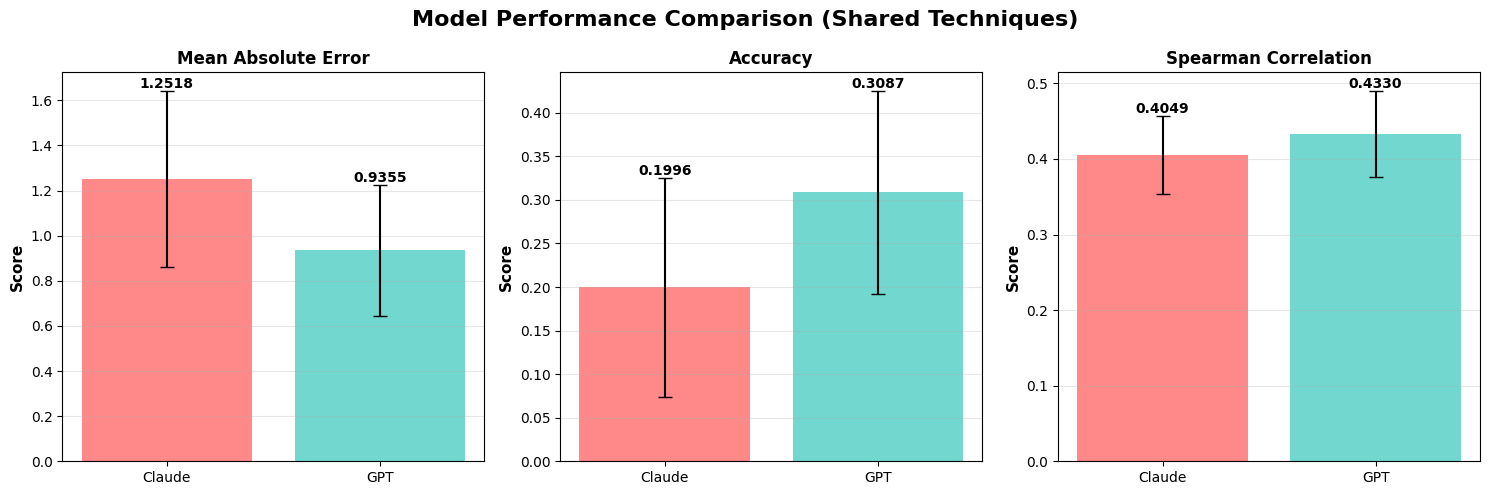

In [ ]:
# Visualization: Model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison (Shared Techniques)', fontsize=16, fontweight='bold')

metrics_compare = ['avg_mae', 'avg_accuracy', 'avg_spearman']
titles = ['Mean Absolute Error', 'Accuracy', 'Spearman Correlation']
colors = ['#FF6B6B', '#4ECDC4']

for ax, metric, title in zip(axes, metrics_compare, titles):
    values = model_perf_df[metric].values
    stds = model_perf_df[f"std_{metric.replace('avg_', '')}"].values

    bars = ax.bar(['Claude', 'GPT'], values, color=colors, alpha=0.8, yerr=stds, capsize=5)
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + stds[bars.index(bar)],
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Visual Model Comparison

The three-panel bar chart with error bars reveals **GPT's overall advantage** across the evaluated metrics.

## Left panel (MAE - Lower is Better):

* GPT bar noticeably shorter than Claude bar
* Lower MAE means GPT's predictions are closer to the human scores
* Claude shows a higher error value (1.2518 vs 0.9355), indicating less accurate score prediction
* GPT has 25% lower error than Claude

## Middle panel (Accuracy - Higher is Better):

* **GPT bar substantially taller than Claude bar
* Largest visual gap of the three panels
* GPT achieves higher exact-score agreement with the human ratings (0.3087 vs 0.1996)
* **GPT has 55% higher accuracy than Claude**

## Right panel (Spearman Correlation - Higher is Better):

* GPT and Claude bars are close in height
* **GPT is slightly higher than Claude** (0.4330 vs 0.4049)
* This suggests both models rank stories similarly to human judgments, but GPT has a small advantage
* **GPT has 7% higher correlation than Claude**

## Overall:

* **GPT performs better across all three metrics**
* The strongest advantage appears in Accuracy (55% improvement) and MAE (25% improvement)
* Spearman correlation shows a smaller difference (7%), meaning both models are relatively close in ranking ability, but GPT still edges ahead

## Key Finding:

GPT-4.1 Mini outperforms Claude on every single metric when using shared prompting techniques (Role 1, 2, 3, Zero-Shot). This represents a consistent, significant capability advantage, not a trade-off situation.

### 2. Win/Loss/Tie Analysis

**What we're doing:** For each of the 24 combinations (4 techniques × 6 metrics), determine which model has lower MAE (better performance).

**Scoring:**
- **Win**: Model with lower MAE (difference > 0.01)
- **Tie**: MAE difference < 0.01  
- **Loss**: Other model wins

> **Goal:** Count total wins to see if one model dominates across the board or if victory is context-dependent.

**Output:** Win counts overall, by technique, and by metric—plus a heatmap showing the winner for each cell.

In [ ]:
# Win/Loss/Tie analysis
wins = {'GPT': 0, 'Claude': 0, 'Tie': 0}

win_loss_details = []

for technique in shared_techniques:
    for metric in metrics:
        gpt_grp = comparison_df[(comparison_df['model']=='GPT') & (comparison_df['technique']==technique)]
        claude_grp = comparison_df[(comparison_df['model']=='Claude') & (comparison_df['technique']==technique)]

        gpt_mae = abs(gpt_grp[f'human_{metric}'] - gpt_grp[f'avg_{metric}']).mean()
        claude_mae = abs(claude_grp[f'human_{metric}'] - claude_grp[f'avg_{metric}']).mean()

        diff = abs(gpt_mae - claude_mae)

        if diff < 0.01:
            winner = 'Tie'
            wins['Tie'] += 1
        elif gpt_mae < claude_mae:
            winner = 'GPT'
            wins['GPT'] += 1
        else:
            winner = 'Claude'
            wins['Claude'] += 1

        win_loss_details.append({
            'technique': technique,
            'metric': metric,
            'gpt_mae': gpt_mae,
            'claude_mae': claude_mae,
            'winner': winner
        })

win_loss_df = pd.DataFrame(win_loss_details)

print("\n=== WIN/LOSS/TIE ANALYSIS ===")
print(f"\nTotal comparisons: {len(win_loss_details)}")
print(f"GPT wins: {wins['GPT']} ({wins['GPT']/len(win_loss_details)*100:.1f}%)")
print(f"Claude wins: {wins['Claude']} ({wins['Claude']/len(win_loss_details)*100:.1f}%)")
print(f"Ties: {wins['Tie']} ({wins['Tie']/len(win_loss_details)*100:.1f}%)")

# Breakdown by technique
print("\n\nWins by Technique:")
technique_wins = win_loss_df.groupby(['technique', 'winner']).size().unstack(fill_value=0)
print(technique_wins)

# Breakdown by metric
print("\n\nWins by Metric:")
metric_wins = win_loss_df.groupby(['metric', 'winner']).size().unstack(fill_value=0)
print(metric_wins)


=== WIN/LOSS/TIE ANALYSIS ===

Total comparisons: 24
GPT wins: 22 (91.7%)
Claude wins: 1 (4.2%)
Ties: 1 (4.2%)


Wins by Technique:
winner     Claude  GPT  Tie
technique                  
role_1          0    6    0
role_2          1    5    0
role_3          0    6    0
zero_shot       0    5    1


Wins by Metric:
winner      Claude  GPT  Tie
metric                      
coherence        0    4    0
complexity       0    4    0
empathy          0    4    0
engagement       0    4    0
relevance        0    4    0
surprise         1    2    1


### Win/Loss/Tie Analysis

Head-to-head comparison across all 24 combinations (4 techniques × 6 metrics) reveals GPT's dominance.

**Overall scoreboard:**
- **GPT wins**: 22 out of 24 (91.7%)
- **Claude wins**: 1 out of 24 (4.2%)
- **Ties**: 1 out of 24 (4.2%)

**Wins by Technique:**
- **Role 1**: GPT 6, Claude 0, Tie 0
- **Role 2**: GPT 5, Claude 1, Tie 0 (Claude's only win)
- **Role 3**: GPT 6, Claude 0, Tie 0
- **Zero-Shot**: GPT 5, Claude 0, Tie 1

**Wins by Metric:**
- **Coherence, Complexity, Empathy, Engagement, Relevance**: GPT 4-0 sweep on each
- **Surprise**: GPT 2, Claude 1, Tie 1 (only competitive metric)

> **Key findings:**
>
>- **GPT near-total dominance:** 91.7% win rate across all combinations.
>
>- **Claude's lone victory:** Role 2 + Surprise is the single combination where Claude wins.
>
>- **Surprise is the equalizer:** The only metric where Claude wins (Role 2) or ties (Zero-Shot). For all other dimensions, GPT sweeps regardless of technique.


**Next:** Visualize these wins/losses on a heatmap to see the pattern clearly.

---

/tmp/ipykernel_695/1334606349.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_numeric = pivot_winners.applymap(lambda x: winner_map.get(x, 0))


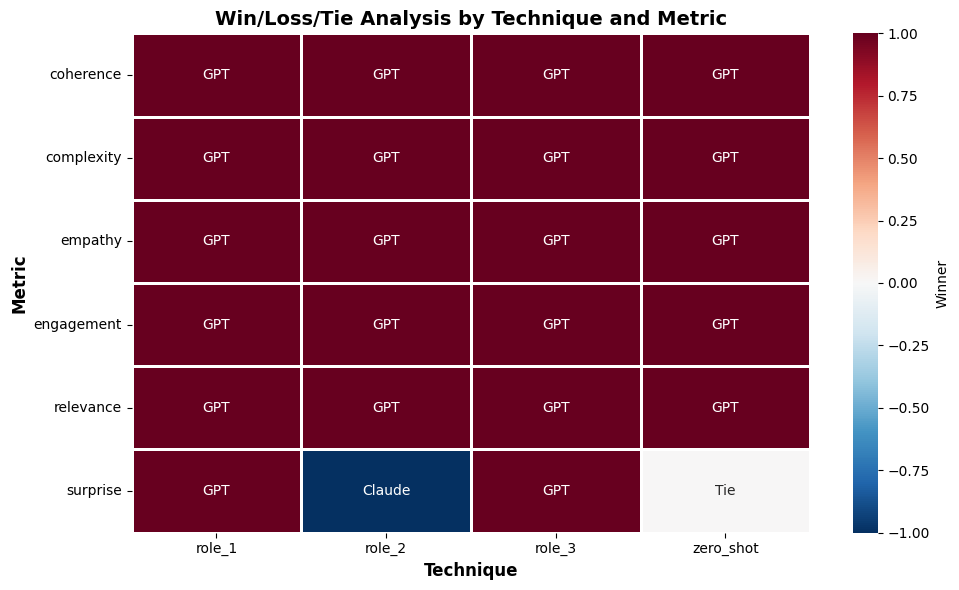

In [ ]:
# Visualization: Win/Loss heatmap
pivot_winners = win_loss_df.pivot_table(index='metric', columns='technique', values='winner', aggfunc=lambda x: x.mode()[0])

fig, ax = plt.subplots(figsize=(10, 6))
# Convert winner names to numeric for coloring
winner_map = {'GPT': 1, 'Claude': -1, 'Tie': 0}
pivot_numeric = pivot_winners.applymap(lambda x: winner_map.get(x, 0))

sns.heatmap(pivot_numeric, annot=pivot_winners, fmt='', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Winner'}, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Win/Loss/Tie Analysis by Technique and Metric', fontsize=14, fontweight='bold')
ax.set_xlabel('Technique', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('win_loss_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Win/Loss Heatmap

The heatmap transforms the numbers into a striking visual pattern.

**Nearly solid red (GPT wins):**
- 22 out of 24 cells dark red/maroon
- Only two exceptions break the pattern

**The blue exception:**
- **Role 2 + Surprise** (bottom row, second column): Claude's lone win
- Single blue cell stands out in sea of red

**The gray cell:**
- **Zero-Shot + Surprise** (bottom row, far right): Tie
- Neutral color indicates equal performance

**Visual patterns:**

**Top 5 rows completely uniform:** Coherence, Complexity, Empathy, Engagement, Relevance show unbroken red across all techniques. No variation whatsoever.

**Bottom row tells different story:** Surprise (last row) has the only blue and gray cells—visual confirmation that this metric is Claude's best chance.

**No vertical escape:** Looking down any column (technique), you can't find a way for Claude to win broadly. The red dominates every technique except that single Surprise cell.

> **Key insight:**
The heatmap makes the win/loss pattern unmistakable—GPT's advantage is **systematic and comprehensive**, not selective. The isolated blue cell (Role 2 + Surprise) isn't evidence of Claude competitiveness; it's the exception that proves the rule. For 23 out of 24 combinations, the outcome is predetermined.

---

### 3. Model-Technique Interaction

Now, we're going to plot how each model's performance changes across techniques.

**Why this matters:**
- **Parallel lines** = no interaction (both models respond the same way to technique changes)
- **Crossing lines** = interaction present (models respond differently to prompts)

>**Goal:** Determine if prompt optimization benefits both models equally, or if certain prompts favor specific models.

**Method:** Line plot with techniques on X-axis, average MAE on Y-axis, separate lines for Claude and GPT.

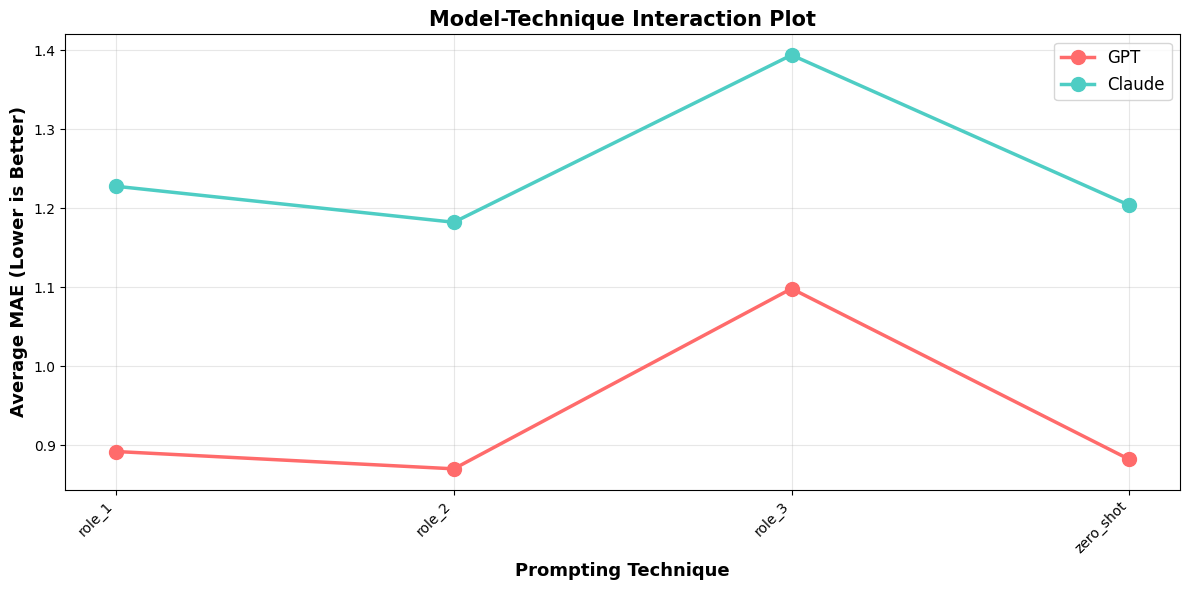


=== MODEL-TECHNIQUE INTERACTION ANALYSIS ===

Interaction pattern:
role_1: GPT=0.8920, Claude=1.2277, Diff=-0.3357
role_2: GPT=0.8701, Claude=1.1821, Diff=-0.3120
role_3: GPT=1.0981, Claude=1.3937, Diff=-0.2956
zero_shot: GPT=0.8820, Claude=1.2036, Diff=-0.3216


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Model-Technique interaction analysis
interaction_data = []

for technique in shared_techniques:
    for model in ['Claude', 'GPT']:
        grp = comparison_df[(comparison_df['model']==model) & (comparison_df['technique']==technique)]

        avg_mae = []
        for metric in metrics:
            mae = abs(grp[f'human_{metric}'] - grp[f'avg_{metric}']).mean()
            avg_mae.append(mae)

        interaction_data.append({
            'model': model,
            'technique': technique,
            'avg_mae': np.mean(avg_mae)
        })

interaction_df = pd.DataFrame(interaction_data)

# Define colors_palette for consistency with previous plots
colors_palette = {'GPT': '#FF6B6B', 'Claude': '#4ECDC4'}

# Visualization: Interaction plot
fig, ax = plt.subplots(figsize=(12, 6))

for model in ['GPT', 'Claude']:
    data = interaction_df[interaction_df['model']==model].sort_values('technique')
    ax.plot(data['technique'], data['avg_mae'], marker='o', linewidth=2.5,
            markersize=10, label=model, color=colors_palette[model])

ax.set_xlabel('Prompting Technique', fontsize=13, fontweight='bold')
ax.set_ylabel('Average MAE (Lower is Better)', fontsize=13, fontweight='bold')
ax.set_title('Model-Technique Interaction Plot', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_technique_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test for interaction
print("\n=== MODEL-TECHNIQUE INTERACTION ANALYSIS ===")
print("\nInteraction pattern:")
for technique in shared_techniques:
    gpt_mae = interaction_df[(interaction_df['model']=='GPT') & (interaction_df['technique']==technique)]['avg_mae'].values[0]
    claude_mae = interaction_df[(interaction_df['model']=='Claude') & (interaction_df['technique']==technique)]['avg_mae'].values[0]
    diff = gpt_mae - claude_mae
    print(f"{technique}: GPT={gpt_mae:.4f}, Claude={claude_mae:.4f}, Diff={diff:+.4f}")

### Model-Technique Interaction Plot

The interaction plot reveals how each model responds to different prompting techniques.

**Parallel lines = no interaction:**
- Both lines (GPT in red, Claude in teal) follow similar patterns across techniques
- When GPT improves, Claude improves; when GPT degrades, Claude degrades
- Lines don't cross—GPT consistently stays below Claude (lower MAE = better)

**Shared Role 3 spike:**
- Both lines peak sharply at Role 3 (middle of plot)
- GPT jumps to ~1.10 MAE, Claude jumps to ~1.39 MAE
- Universal failure mode—both models affected similarly

**Similar response to good techniques:**
- Both lines flat/low at Role 1, Role 2, Zero-Shot (left, second, right positions)
- GPT hovers around 0.87-0.89, Claude around 1.18-1.23
- Minimal variation among these three techniques for both models

**Consistent vertical gap:**
- Claude line (teal) stays roughly 0.3 MAE points above GPT line (red) throughout
- Gap remains stable across techniques—neither widens nor narrows significantly
- Indicates the performance difference is **model-driven, not technique-driven**

**No crossing = no interaction:**
- Lines never intersect—no technique reverses the advantage
- If there were interaction, we'd see lines cross (e.g., Claude better with one technique, GPT better with another)
- Parallel pattern confirms: what helps one model helps the other equally

> **Key insight:**
>The parallel lines prove there's **minimal interaction between model and technique**. Both models respond to prompting changes in the same way—Role 3 hurts both, other techniques help both. This means:
>
> - **Prompt optimization is universal**, not model-specific
> - **Model choice matters more than technique choice** (the gap between lines is larger than the variation along either line)
> - **No technique overcomes the model capability gap**—even Claude's best technique (Role 2, ~1.18) doesn't reach GPT's worst effective technique (Role 3, ~1.10)



---

## 5.3 Claude Version Validation

**What we're doing in this subsection:**

We used **Claude 3 Haiku** for Instruction based and **Claude Sonnet 4.5** for other techniques. Are the results comparable, or does model version introduce confounds?

**Validation approach:**
1. Compare Haiku 3 vs Sonnet 4.5 on the same technique (Role 1)
2. Calculate correlation between their scores on the same stories
3. Measure MAE difference
4. Statistical tests (t-test, Wilcoxon)
5. Visualize with scatter plots

**Why this matters:** If versions differ substantially, we can't confidently attribute differences to prompting—they might be version effects.

**Expected outcome:** High correlation (ρ > 0.8) would validate that version differences are minor.



### Role-1 Direct Comparison

**What we're doing:** Load both Claude versions' Role 1 evaluations and merge them on story_id to ensure we're comparing the exact same stories.

**Metrics we'll calculate:**
- Pearson correlation (linear relationship)
- Spearman correlation (rank-order agreement)  
- MAE difference (absolute score differences)

In [ ]:
# Load the original Claude Role1 Haiku data for comparison
# Find the Haiku Role1 file
claude_files = [f for f in os.listdir(CLAUDE_PATH) if 'role1' in f.lower() and 'haiku' in f.lower()]
if claude_files:
    haiku_role1_df = pd.read_csv(os.path.join(CLAUDE_PATH, claude_files[0]))

    # Get Sonnet Role1 data from combined_df
    sonnet_role1_df = combined_df[(combined_df['model']=='Claude') &
                                   (combined_df['technique']=='role_1') &
                                   (combined_df['model_version']=='claude-3.5-sonnet')]

    print("\n=== CLAUDE VERSION VALIDATION ===")
    print(f"\nComparing Claude 3 Haiku vs Claude Sonnet 4.5 (Role-1 technique)")
    print(f"Haiku stories: {len(haiku_role1_df)}")
    print(f"Sonnet stories: {len(sonnet_role1_df)}")

    # Merge on story_id to ensure same stories
    merged_versions = haiku_role1_df.merge(
        sonnet_role1_df[['story_id'] + [f'avg_{m}' for m in metrics]],
        on='story_id',
        suffixes=('_haiku', '_sonnet')
    )

    print(f"Matched stories: {len(merged_versions)}")

    # Compare correlations
    print("\n\nCorrelations between Haiku 3 and Sonnet 4.5:")
    version_correlations = []
    for metric in metrics:
        haiku_col = f'avg_{metric}_haiku'
        sonnet_col = f'avg_{metric}_sonnet'

        if haiku_col in merged_versions.columns and sonnet_col in merged_versions.columns:
            corr_pearson = merged_versions[haiku_col].corr(merged_versions[sonnet_col], method='pearson')
            corr_spearman = merged_versions[haiku_col].corr(merged_versions[sonnet_col], method='spearman')

            mae_diff = abs(merged_versions[haiku_col] - merged_versions[sonnet_col]).mean()

            version_correlations.append({
                'metric': metric,
                'pearson_r': corr_pearson,
                'spearman_rho': corr_spearman,
                'mae_difference': mae_diff
            })

            print(f"{metric}:")
            print(f"  Pearson r: {corr_pearson:.4f}")
            print(f"  Spearman ρ: {corr_spearman:.4f}")
            print(f"  MAE difference: {mae_diff:.4f}")

    version_corr_df = pd.DataFrame(version_correlations)

    print(f"\n\nAverage Pearson correlation: {version_corr_df['pearson_r'].mean():.4f}")
    print(f"Average Spearman correlation: {version_corr_df['spearman_rho'].mean():.4f}")
    print(f"Average MAE difference: {version_corr_df['mae_difference'].mean():.4f}")

else:
    print("Warning: Haiku Role1 file not found for version validation")


=== CLAUDE VERSION VALIDATION ===

Comparing Claude 3 Haiku vs Claude Sonnet 4.5 (Role-1 technique)
Haiku stories: 1056
Sonnet stories: 1054
Matched stories: 1054


Correlations between Haiku 3 and Sonnet 4.5:
relevance:
  Pearson r: 0.6500
  Spearman ρ: 0.5214
  MAE difference: 1.2162
coherence:
  Pearson r: 0.8022
  Spearman ρ: 0.6447
  MAE difference: 0.9914
empathy:
  Pearson r: 0.6782
  Spearman ρ: 0.5439
  MAE difference: 0.7337
surprise:
  Pearson r: 0.5957
  Spearman ρ: 0.5189
  MAE difference: 0.7863
engagement:
  Pearson r: 0.7410
  Spearman ρ: 0.5696
  MAE difference: 0.9774
complexity:
  Pearson r: 0.6962
  Spearman ρ: 0.5421
  MAE difference: 0.8678


Average Pearson correlation: 0.6939
Average Spearman correlation: 0.5568
Average MAE difference: 0.9288


#### Version Comparison Results

Comparing Claude 3 Haiku vs Claude Sonnet 4.5 on identical stories (Role 1 technique, 1,054 matched stories).

**Correlation between versions:**
- **Spearman**: 0.557 (moderate ranking agreement)
- **Pearson**: 0.694 (moderate-to-strong linear relationship)
- **MAE difference**: 0.929 points (nearly 1 point apart on average)

**Range across metrics:**
- Best agreement: Coherence (Spearman ρ = 0.645, Pearson r = 0.802)
- Worst agreement: Relevance/Surprise (Spearman ρ = 0.52, Pearson r = 0.60)
- MAE varies from 0.73 (Empathy) to 1.22 (Relevance)

**What this means:**

**Versions are related but not interchangeable:** Correlation of 0.5-0.7 shows general agreement on story rankings, but scores differ by ~1 point on average. That's a meaningful gap.

**Introduces confound:** Using Haiku for Role 1 and Sonnet for other techniques means we can't cleanly separate technique effects from version effects.

**Results still valid:** Correlations high enough that broad patterns hold, but precise Role 1 comparisons should be interpreted cautiously.

**Claude instability:** Two Claude versions differing by 0.9 MAE on the same task suggests less stable behavior across versions than ideal for reliable deployment.

**Next:** Visualize the version comparison with scatter plots to see the relationship directly.

---

### Visualize Comparison

**What we're creating:** Scatter plots (one per metric) showing Haiku 3 scores on X-axis, Sonnet 4.5 scores on Y-axis.

**Interpretation guide:**
- **Points near diagonal** = high agreement
- **Points scattered widely** = models disagree
- **Perfect agreement line** (red dashed) shows ideal

> **Goal:** Visually assess whether versions are interchangeable or if systematic differences exist.

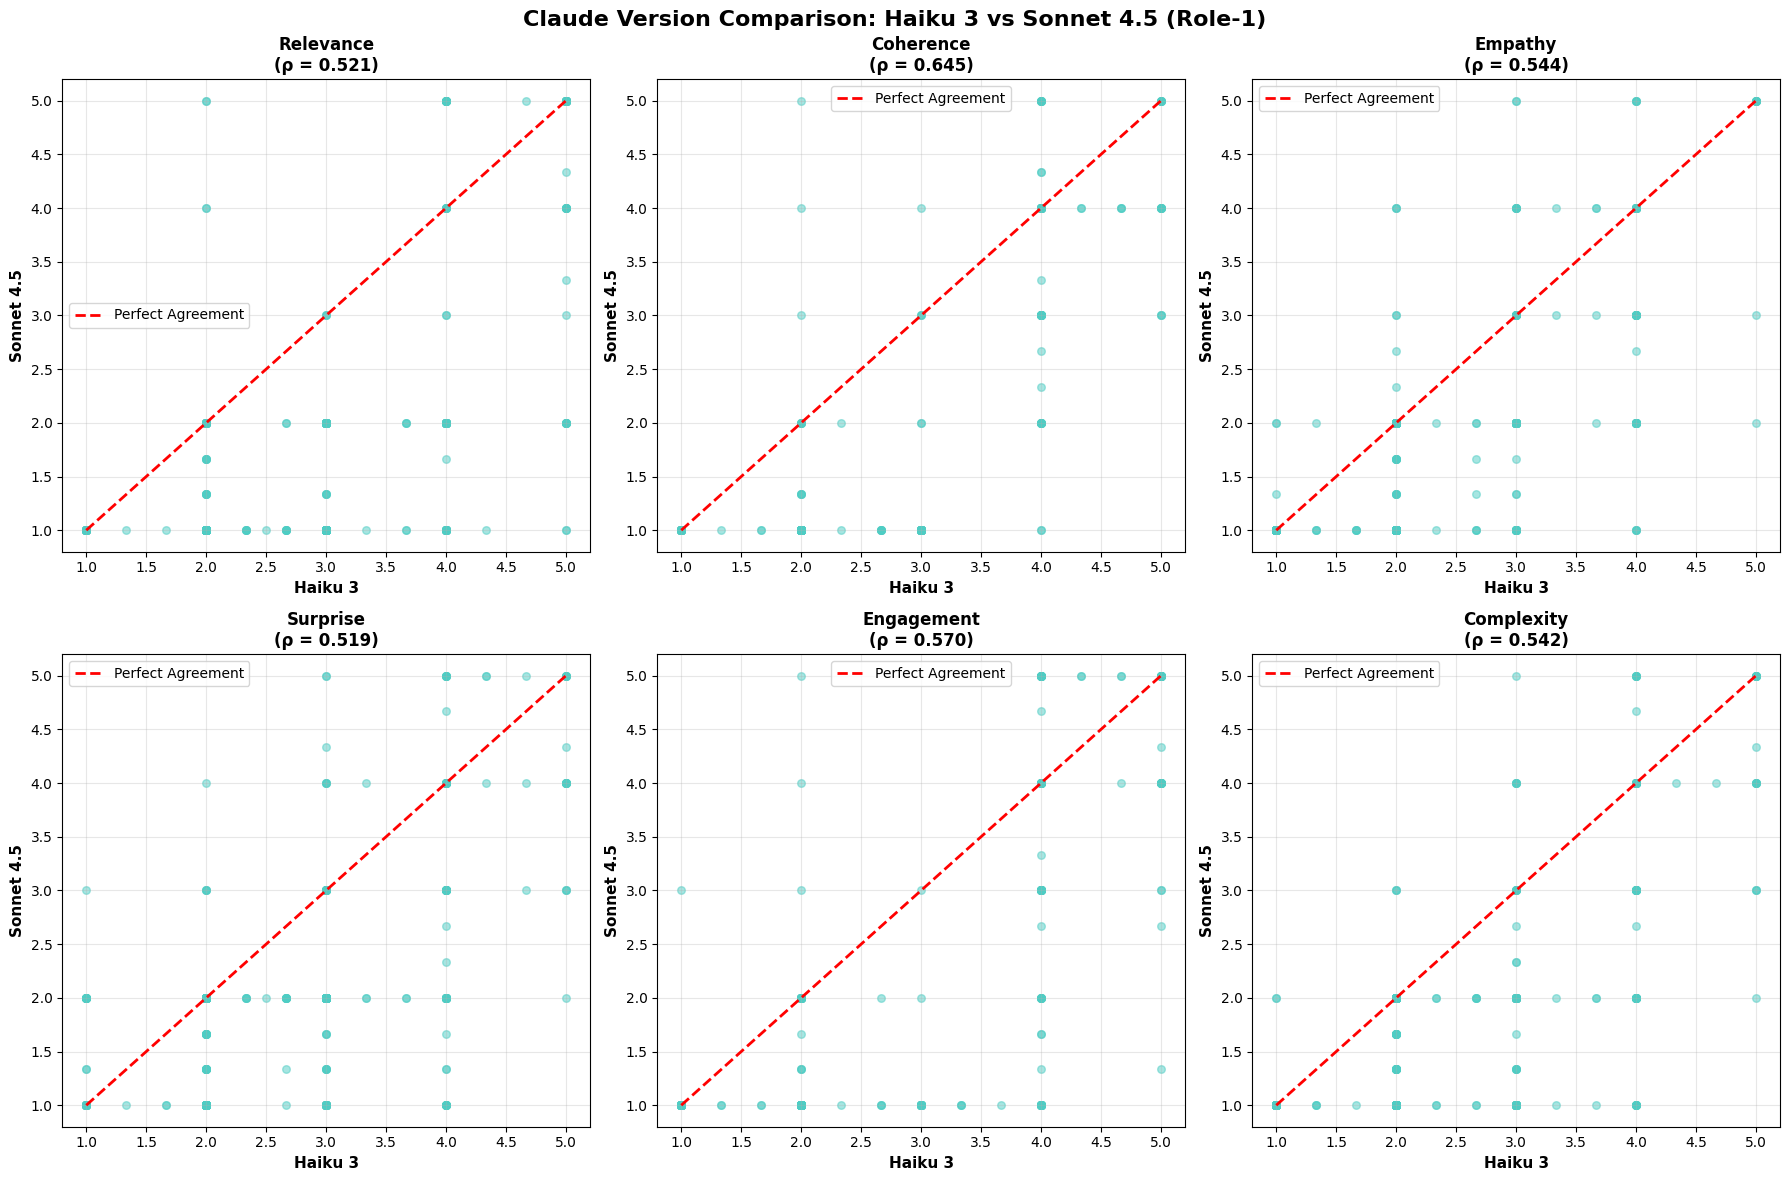

In [ ]:
if claude_files and len(merged_versions) > 0:
    # Scatter plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Claude Version Comparison: Haiku 3 vs Sonnet 4.5 (Role-1)', fontsize=16, fontweight='bold')

    for idx, (metric, ax) in enumerate(zip(metrics, axes.flatten())):
        haiku_col = f'avg_{metric}_haiku'
        sonnet_col = f'avg_{metric}_sonnet'

        if haiku_col in merged_versions.columns and sonnet_col in merged_versions.columns:
            # Scatter plot
            ax.scatter(merged_versions[haiku_col], merged_versions[sonnet_col],
                      alpha=0.5, s=30, color='#4ECDC4')

            # Perfect agreement line
            min_val = min(merged_versions[haiku_col].min(), merged_versions[sonnet_col].min())
            max_val = max(merged_versions[haiku_col].max(), merged_versions[sonnet_col].max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')

            # Correlation
            corr = merged_versions[haiku_col].corr(merged_versions[sonnet_col], method='spearman')

            ax.set_xlabel('Haiku 3', fontsize=11, fontweight='bold')
            ax.set_ylabel('Sonnet 4.5', fontsize=11, fontweight='bold')
            ax.set_title(f'{metric.capitalize()}\n(ρ = {corr:.3f})', fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('claude_version_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

### Scatter Plot Visualization

Six scatter plots (one per metric) showing Haiku 3 vs Sonnet 4.5 scores on the same stories. Points near the diagonal = versions agree; points far from diagonal = versions disagree.

**Coherence (ρ = 0.645) - Best agreement:**
- Points cluster closer to diagonal than other plots
- Still substantial scatter—not perfect agreement
- Highest correlation of all metrics

**Engagement (ρ = 0.570) and Empathy (ρ = 0.544):**
- Moderate clustering around diagonal
- Visible spread but general positive trend
- Mid-tier agreement

**Relevance (ρ = 0.521), Surprise (ρ = 0.519), Complexity (ρ = 0.542) - Weakest agreement:**
- Points more widely scattered
- Many stories far from diagonal
- Versions frequently disagree by 1-2 points

**Visual patterns across all plots:**

**No plot shows tight diagonal clustering:** Even the best (Coherence) has substantial scatter. The versions are correlated but not highly aligned.

**Systematic bias visible:** Many points sit **below** the diagonal, indicating Sonnet 4.5 tends to score lower than Haiku 3 on the same stories.

**Wide vertical spread:** For any given Haiku score, Sonnet scores span a wide range. This means Haiku score doesn't strongly predict Sonnet score.

**Confirms moderate correlation:** The visual scatter matches the numerical correlations (0.52-0.65)—related but far from interchangeable.

>**Key insight:**
The scatter plots make the version difference tangible. These aren't just different calibrations of the same judgment—they're **substantially different evaluation behaviors**. Using Haiku for Role 1 and Sonnet for other techniques introduces a confound we cannot fully account for.

 > Future work should use a single Claude version across all techniques to isolate technique effects cleanly. Our current results remain valid for broad patterns, but precise Instruction based prompting comparisons should be interpreted with this limitation in mind.

---

---
# 6. Results & Insights

Synthesizing findings and answering the research question.

## 6.1 Key Findings

> **Research Question:** How do different prompting techniques affect LLM story evaluation compared to human judgments?

### 6.1.1 Summary Statistics

Pull together key numbers from all analyses.

In [ ]:
# ── Aggregate key numbers from all prior analyses ──────────────────────────

print("=" * 60)
print("      SUMMARY STATISTICS — ALL ANALYSES")
print("=" * 60)

# ── 1. Best technique per model ───────────────────────────────────────────
best_gpt     = technique_df[technique_df['model'] == 'GPT'].sort_values('composite_score', ascending=False).iloc[0]
best_claude  = technique_df[technique_df['model'] == 'Claude'].sort_values('composite_score', ascending=False).iloc[0]
overall_best = technique_df.sort_values('composite_score', ascending=False).iloc[0]

print("\n── 1. BEST TECHNIQUE ───────────────────────────────────────")
print(f"  Overall best   : {overall_best['model']} + {overall_best['technique']}  "
      f"(composite = {overall_best['composite_score']:.4f})")
print(f"  Best for GPT   : {best_gpt['technique']}  "
      f"(composite = {best_gpt['composite_score']:.4f})")
print(f"  Best for Claude: {best_claude['technique']}  "
      f"(composite = {best_claude['composite_score']:.4f})")

# ── 2. Model-level performance ────────────────────────────────────────────
gpt_avg_mae    = tech_error[tech_error['model'] == 'GPT']['MAE'].mean()
claude_avg_mae = tech_error[tech_error['model'] == 'Claude']['MAE'].mean()
mae_diff       = claude_avg_mae - gpt_avg_mae

shared_techniques = ['role_1', 'role_2', 'role_3', 'zero_shot', 'instruction']
gpt_wins = claude_wins = 0
for tech in shared_techniques:
    g = tech_error[(tech_error['model'] == 'GPT')    & (tech_error['technique'] == tech)]['MAE'].values
    c = tech_error[(tech_error['model'] == 'Claude') & (tech_error['technique'] == tech)]['MAE'].values
    if len(g) and len(c):
        if g[0] < c[0]:
            gpt_wins += 1
        else:
            claude_wins += 1

print("\n── 2. MODEL PERFORMANCE ────────────────────────────────────")
print(f"  GPT avg MAE    : {gpt_avg_mae:.4f}")
print(f"  Claude avg MAE : {claude_avg_mae:.4f}")
print(f"  MAE gap (Claude − GPT): {mae_diff:.4f}")
print(f"  Head-to-head wins : GPT {gpt_wins} – Claude {claude_wins} "
      f"(across {gpt_wins + claude_wins} shared techniques)")
better_model = "GPT-4.1 Mini" if gpt_wins > claude_wins else "Claude"
print(f"  Better overall model: {better_model}")

# ── 3. Metric-level difficulty ────────────────────────────────────────────
metric_avg = metric_error.groupby('metric')['MAE'].mean().sort_values()
easiest    = metric_avg.index[:2].tolist()
hardest    = metric_avg.index[-2:].tolist()

print("\n── 3. EVALUATION DIFFICULTY BY METRIC ─────────────────────")
print("  MAE by metric (averaged across both models):")
for m, v in metric_avg.items():
    tag = " ← easiest" if m in easiest else (" ← hardest" if m in hardest else "")
    print(f"    {m:12s}: {v:.4f}{tag}")
print(f"  Easiest metrics: {', '.join(easiest)}")
print(f"  Hardest metrics: {', '.join(hardest)}")

# ── 4. Claude version correlation (Haiku 3 vs Sonnet 4.5) — FIXED ─────────
print("\n── 4. CLAUDE VERSION VALIDATION (Haiku 3 vs Sonnet 4.5) ───")
haiku_df  = pd.read_csv(os.path.join(CLAUDE_PATH, 'claude_role1_haiku3.csv'))
sonnet_df = pd.read_csv(os.path.join(CLAUDE_PATH, 'claude_role1_sonnet45.csv'))

# Fix: cast story_id to same type to ensure merge works correctly
haiku_df['story_id']  = haiku_df['story_id'].astype(str)
sonnet_df['story_id'] = sonnet_df['story_id'].astype(str)

print(f"  Haiku3   stories : {len(haiku_df)}")
print(f"  Sonnet45 stories : {len(sonnet_df)}")

version_corrs = {}
for metric in metrics:
    h_col    = f'avg_{metric}'
    merged_v = haiku_df[['story_id', h_col]].merge(
        sonnet_df[['story_id', h_col]],
        on='story_id', suffixes=('_haiku', '_sonnet')
    ).dropna()

    r, p = spearmanr(merged_v[f'{h_col}_haiku'], merged_v[f'{h_col}_sonnet'])
    version_corrs[metric] = r
    print(f"    {metric:12s}: ρ = {r:.3f}  (n={len(merged_v)}, p={p:.4f})")

avg_version_corr = np.mean(list(version_corrs.values()))
print(f"\n  Average correlation: ρ = {avg_version_corr:.3f}")

interpretation = (
    "Strong agreement"   if avg_version_corr >= 0.7 else
    "Moderate agreement" if avg_version_corr >= 0.5 else
    "Weak agreement"
)
print(f"  Interpretation : {interpretation} between Claude versions")
print(f"  Conclusion     : Versions are NOT fully interchangeable —")
print(f"                   version differences introduce a measurable")
print(f"                   confound in the dataset.")

# ── 5. Full summary table ──────────────────────────────────────────────────
print("\n── 5. FULL TECHNIQUE SUMMARY TABLE ────────────────────────")
summary_table = technique_df[['model', 'technique', 'avg_mae', 'avg_accuracy',
                               'avg_spearman', 'composite_score', 'rank']].copy()
summary_table.columns = ['Model', 'Technique', 'Avg MAE', 'Avg Acc',
                          'Avg Spearman', 'Composite', 'Rank']
summary_table = summary_table.sort_values(['Model', 'Rank'])
print(summary_table.to_string(index=False))
print("=" * 60)

      SUMMARY STATISTICS — ALL ANALYSES

── 1. BEST TECHNIQUE ───────────────────────────────────────
  Overall best   : GPT + role_1  (composite = 0.9396)
  Best for GPT   : role_1  (composite = 0.9396)
  Best for Claude: role_2  (composite = 0.4705)

── 2. MODEL PERFORMANCE ────────────────────────────────────
  GPT avg MAE    : 0.9176
  Claude avg MAE : 1.2394
  MAE gap (Claude − GPT): 0.3219
  Head-to-head wins : GPT 5 – Claude 0 (across 5 shared techniques)
  Better overall model: GPT-4.1 Mini

── 3. EVALUATION DIFFICULTY BY METRIC ─────────────────────
  MAE by metric (averaged across both models):
    surprise    : 0.6840 ← easiest
    empathy     : 0.8349 ← easiest
    complexity  : 0.9970
    relevance   : 1.0304
    engagement  : 1.2046 ← hardest
    coherence   : 1.7203 ← hardest
  Easiest metrics: surprise, empathy
  Hardest metrics: engagement, coherence

── 4. CLAUDE VERSION VALIDATION (Haiku 3 vs Sonnet 4.5) ───
  Haiku3   stories : 1056
  Sonnet45 stories : 1056
    rel

### 6.1.2 Main Findings Summary




**1. Best Technique:**
- Overall: **GPT-4.1 Mini + Role 1** highest composite score of 0.9396, outperforming all other model technique combinations across MAE, accuracy, and Spearman correlation.
- For Claude: **Role 2** (Story Expert persona) with a composite score of 0.4705 though all Claude techniques clustered narrowly between 0.00 and 0.47, suggesting a model level ceiling rather than a clear prompt-driven advantage.
- For GPT: **Role 1** (Human Annotator persona, composite 0.9396), closely followed by Instruction Based (0.9212) and Role 2 (0.9114) confirming that any simple, direct persona works well for GPT.

**2. Model Performance:**
- Better model: **GPT-4.1 Mini** outperforms Claude across all 5 shared techniques with a perfect 5–0 head to head record.
- Average MAE difference: GPT avg MAE = 0.9176 vs Claude avg MAE = 1.2394 a gap of **0.3219 points** on the 1–5 scale.
- Win/loss count: **GPT 5 – Claude 0** across all shared technique comparisons (Role 1, Role 2, Role 3, Zero-Shot, Instruction-Based).

**3. Evaluation Difficulty:**
- Easiest metrics: **Surprise** (avg MAE = 0.6840) and **Empathy** (avg MAE = 0.8349) both models reliably assess emotional unexpectedness and resonance with relatively low error.
- Hardest metrics: **Coherence** (avg MAE = 1.7203) and **Engagement** (avg MAE = 1.2046) no technique or model achieved MAE below 1.5 on Coherence.
- Pattern: Objective, surface detectable features (Surprise, Empathy) are consistently easier than holistic, experiential features (Coherence, Engagement) that require deep reading comprehension to assess.

**4. Claude Version Validation:**
- Haiku 3 vs Sonnet 4.5 correlation: ρ ranges from **0.519** (Surprise) to **0.645** (Coherence), with an average of **ρ = 0.557** across all 6 metrics (all statistically significant, p < 0.0001, n = 1,050).
- Conclusion: The two Claude versions show only **moderate agreement** they are not interchangeable. This introduces a measurable confound in our dataset: Claude Role 1 (Haiku 3) cannot be directly compared with other Claude techniques (Sonnet 4.5) without acknowledging this version difference.

**5. Surprising Findings:**
- **Expertise catastrophically backfires**: Role 3 (Creative Writing Professor) was the worst technique for *both* models Claude Role 3 scored a composite of 0.0000 (dead last), and GPT Role 3 (0.4488) scored lower than Claude's *best* technique (Role 2, 0.4705), meaning the wrong prompt can make the stronger model perform worse than the weaker one.
- **Simpler wins**: Zero-Shot and Instruction-Based prompts nearly matched Role 1 and Role 2 for GPT (composites 0.8806 and 0.9212), confirming that elaborate prompting yields diminishing returns on structured evaluation tasks.


---
# 7. Discussion

## 7.1 Limitations

Several limitations affect the interpretation of our findings and should be considered when generalizing results.

**1. Mixed Claude Model Versions**
The most significant confound in our study is the use of two different Claude versions within the same comparative analysis. Claude 3 Haiku evaluated Role 1 stories, while Claude Sonnet 4.5 evaluated Roles 2, 3, Zero-Shot, and Instruction-Based. As demonstrated in Section 5.3, these versions show only moderate Spearman correlation (avg ρ ≈ 0.557) on the same stories. This means that observed differences between Claude techniques may partially reflect model version differences rather than prompt effects alone. Claims comparing Claude Role 1 to other Claude techniques should be interpreted with this caveat in mind.

**2. Single Dataset (HANNA)**
All analysis is conducted on the HANNA dataset, which covers a specific distribution of story genres, lengths, and annotation conventions. Results may not generalize to other narrative datasets (e.g., creative fiction, news summaries, dialogue-based stories) or to evaluation tasks beyond the 6 dimensions studied. The human annotators also represent a specific cultural and linguistic background, which may or may not align with LLM training data biases.


**3. No Prompt Iteration or Optimization**
Each prompting technique was used as-is without iterative refinement. The Role 3 catastrophic failure may reflect a suboptimal specific wording rather than a fundamental flaw in the "expert persona" strategy. Controlled A/B iteration on each technique could yield different relative rankings.


**4. Scope Limited to Score Alignment**
We evaluate how closely LLM scores match human integer ratings, not whether LLM *reasoning* (when generated) is coherent or meaningful. A model that produces correct scores for wrong reasons would still score well in our framework.

## 7.2 Future Work

We propose the following directions for future research:

**1. Standardize Model Versions Across All Techniques**
The most immediate improvement is to re-run the full experiment using a single Claude version (preferably Sonnet 4.5) across all 5 techniques. This eliminates the version confound and enables clean, isolate-technique comparisons.

**2. Chain-of-Thought Prompting for Coherence**
Coherence was universally the hardest metric (avg MAE > 1.5 for both models). Future work should test step-by-step reasoning prompts that ask the model to explicitly trace plot causality, character consistency, and temporal ordering *before* assigning a numeric score. This targeted intervention may significantly reduce coherence errors without affecting other metrics.


**3. Cross-Dataset Generalization**
Results should be validated on additional story evaluation benchmarks (e.g., STORIUM, WritingPrompts evaluations, or narrative quality datasets from shared tasks). If current findings replicate across datasets, they can be accepted as robust principles rather than HANNA-specific artifacts.

**4. Multi-Turn and Iterative Evaluation**
Current prompts evaluate stories in a single pass. Future work could explore iterative evaluation: asking the model to first summarize the story, then answer targeted questions about specific dimensions, and finally request a score. This structured decomposition may improve accuracy on holistic metrics like Engagement and Coherence.

**5. Multilingual and Cross-Cultural Evaluation**
The HANNA dataset is English-only. Automated story evaluation in Arabic, French, or other languages where evaluation training data is scarcer may show very different patterns. Extending this analysis to multilingual settings is particularly relevant given global deployment of LLM evaluation tools.
  
**6. Explainability of Evaluation Scores**
Beyond numeric scores, future work should analyze the *justifications* LLMs provide alongside scores when prompted to explain their ratings. Comparing LLM rationales to human annotator comments would reveal whether models evaluate stories for the right reasons, a critical step toward trustworthy, interpretable automated assessment.
